### Imports

In [ ]:
import abmax.structs as abx_struct
from jax import config
config.update("jax_enable_x64", True)
import abmax.functions as abx_func
import jax.numpy as jnp
import jax.random as random
import jax
import numpy as np
import matplotlib.pyplot as plt
from flax import struct
from abmax.structs import *
import importlib
import benchmark_adapter
import benchmarks_2D as b2d
import benchmarks_CEC as bcec
from benchmark_adapter import get_bounds, get_objective_name, make_objective_fn
import time
import pandas as pd
import importlib
import benchmarks_CEC as bcec
import benchmark_adapter as badapter
import gc
import inspect
from pathlib import Path
from datetime import datetime
from matplotlib.lines import Line2D

importlib.reload(bcec)
importlib.reload(badapter)

<module 'benchmark_adapter' from 'c:\\Users\\kvrgi\\Desktop\\Thesis---Sandro\\Thesis_code\\benchmark_adapter.py'>

## Defining the agents functions

In [ ]:
@struct.dataclass
class Forager(abx_struct.Agent):
    @staticmethod
    def create_agent(type,params: abx_struct.Params | None,id: jnp.int32,active_state: bool,key: jax.random.PRNGKey):
        """
        Creating a single agent
        returns an agent with random position in the search space, and fitness set to infinity.
        """

        # Allows for extrenal overides, but enables the use of defined hyperparamaters if none are inputed
        incoming = {} if (params is None or not hasattr(params, "content")) else params.content
        # Sampling helper hyperparamater
        bounds = incoming["bounds"].astype(jnp.float64)

        incoming = dict(incoming)
        incoming["bounds"] = bounds

        # Paramaters object and agent carries agent_params
        agent_params = abx_struct.Params(content=incoming)

        # Random uniform initialization  
        # Gets number of dimensions in the search space
        d = bounds.shape[0]

        # Each agent gets different key
        lo, hi = bounds[:, 0], bounds[:, 1]
        pos = random.uniform(key, (d,), minval=lo, maxval=hi, dtype=bounds.dtype)


        # Evaluating the agents starting position when initialized placeholder
        fit_placeholder = jnp.asarray(jnp.inf, dtype=pos.dtype)

        # State 
        state_content = {
            'pos': pos,                                  
            'fit': fit_placeholder,                                  
            'best_pos': pos,                             
            'best_fit': fit_placeholder,                             
            'evals': jnp.asarray(0, jnp.int32),          
        }
        # States which agent carries
        agent_state = abx_struct.State(content=state_content)   
        
        return Forager(params=agent_params, id=id, state=agent_state, agent_type=type, key=key, policy=None, age=jnp.asarray(0.0, dtype=pos.dtype), active_state=active_state)
    
    @staticmethod
    def create_agent_at_pos(type,params: abx_struct.Params | None,id: jnp.int32, active_state: bool,key: jax.random.PRNGKey, pos: jnp.ndarray):
        """
        Creating a single agent at a given position
        Returns an agent at a given position in the search space, and fitness set to infinity.
        """

        # Allows for extrenal overides, but enables the use of defined hyperparamaters if none are inputed
        incoming = {} if (params is None or not hasattr(params, "content")) else params.content

        # Paramaters object and agent carries agent_params
        agent_params = abx_struct.Params(content=incoming)

        # Evaluating the agents starting position when initialized
        fit_placeholder = jnp.asarray(jnp.inf, dtype=pos.dtype)

        # State 
        state_content = {
            'pos': pos,                                 
            'fit': fit_placeholder,                                  
            'best_pos': pos,                             
            'best_fit': fit_placeholder,                             
            'evals': jnp.asarray(0, jnp.int32),          
        }
        # States which agent carries
        agent_state = abx_struct.State(content=state_content)  
        return Forager(params=agent_params,id=id,state=agent_state,agent_type=type,key=key,policy=None,age=jnp.asarray(0.0, jnp.float32),active_state=active_state)
    
    @staticmethod
    def sort_agents_by_fitness(agents):
        """
        Sort agents in ascending order of fitness.
        (Best agent first, worst agent last.)

        Args:
            agents: batched Agent/Forager pytree .

        Returns:
            agents_sorted: same structure, sorted by fitness.
            sorted_idx:   indices such that fitness[sorted_idx] is ascending.
        """
        # Getting fitness values
        fit_all = agents.state.content["fit"]
        # Flattening fitness to 1D array
        quantity = jnp.reshape(fit_all, (-1,))
        # Sorting ascending order
        sorted_idx = jnp.argsort(quantity)
        # Generating sorted agents
        agents_sorted = jax.tree_util.tree_map(lambda x: jnp.take(x, sorted_idx, axis=0), agents)

        return agents_sorted, sorted_idx

## Initialization functions

In [7]:

def evaluate_positions(pos: jnp.ndarray, objective_fn) -> jnp.ndarray:
    """
    Vectorized objective evaluation.
    """
    fit = jax.vmap(objective_fn)(pos)
    return fit.astype(jnp.float32)

def initialize_fitness_in_agents(agents, fit: jnp.ndarray,*, set_best: bool,set_evals_to: int | None):
    """
    Set fitness values in agents'state, used in initialization
    step of the algorithm.
    Returns updated agents with fitness set, and optionally also best fitness/pos and evals.
     """
    state = dict(agents.state.content)  
    state["fit"] = fit

    if set_best:
        state["best_fit"] = fit
        state["best_pos"] = state["pos"]  # whatever the agent currently stores as pos

    if set_evals_to is not None:
        N = state["pos"].shape[0]  # number of agents
        state["evals"] = jnp.full((N,), set_evals_to, dtype=jnp.int32)

    return agents.replace(state=agents.state.replace(content=state))

def init_random_agents(key, *, num_agents: int, agent_type: jnp.ndarray, agent_params, objective_fn):
    """
    Randomly generating N agents ia a vectorized way, then explicitly evaluating fitness and writing it back.

    Returns:
      key, agents, ids
    """
    # Creating ids and active flags for agents
    ids = jnp.arange(num_agents, dtype=jnp.int32)
    active = jnp.ones(num_agents, dtype=bool)

    # Split key into one subkey per agent
    key, key_agents = random.split(key)
    subkeys = jax.vmap(lambda i: random.fold_in(key_agents, i))(ids)

    # Creating agents
    agents = jax.vmap(Forager.create_agent, in_axes=(None, None, 0, 0, 0))(agent_type, agent_params, ids, active, subkeys)

    # Extracting positions and fitnesses from the batched agents
    pos = agents.state.content["pos"]
    fit = evaluate_positions(pos, objective_fn)

    # Writing back evaluated fitness into agents state
    agents = initialize_fitness_in_agents(agents, fit, set_best=True, set_evals_to=1)

    return key, agents, ids

def init_qop_agents(key,*, agents, ids_base: jnp.ndarray, lo: jnp.ndarray, hi: jnp.ndarray, agent_type: jnp.ndarray, agent_params, objective_fn):
    """
    Generating quasi-opposite positions from original pos, create N quasi agents at those positions,
       then explicitly evaluate fitness and write it back.

    Returns:
      key, agents_qop
    
    """
    # Extracting positions from the original agents
    pos = agents.state.content["pos"]
    # Bounds and center
    center = (lo + hi) / 2.0
    # Finding oposite position for each agent
    pos_op = lo + hi - pos

    # Generating quasi opposite position - random uniform sampling between center and pos_op
    key, key_q = random.split(key)
    u = random.uniform(key_q, shape=pos.shape)
    q_low = jnp.minimum(center, pos_op)
    q_high = jnp.maximum(center, pos_op)
    pos_qop = q_low + u * (q_high - q_low)

    # Quasi agent ids: offset by N
    num_agents = ids_base.shape[0]
    ids_qop = ids_base + num_agents
    active_qop = jnp.ones(num_agents, dtype=bool)

    # Random keys for quasi agents
    key, key_q_agents = random.split(key)
    subkeys_q = jax.vmap(lambda i: random.fold_in(key_q_agents, i))(ids_qop)

    # Creating quasi agents 
    agents_qop = jax.vmap(Forager.create_agent_at_pos, in_axes=(None, None, 0, 0, 0, 0))(agent_type, agent_params, ids_qop, active_qop, subkeys_q, pos_qop)

    # Evaluation step for quasi agents
    fit_qop = evaluate_positions(pos_qop, objective_fn)
    agents_qop = initialize_fitness_in_agents(agents_qop, fit_qop, set_best=True, set_evals_to=1)

    return key, agents_qop

def select_best_half_after_qobl(agents, agents_qop):
    """
    Combining original + quasi agents, sort by fitness ascending, keep best N/2.
    Returns the kept agents, and their origin flags (0=original, 1=quasi).
    """
    num_agents = agents.state.content["fit"].shape[0] # number of original agents (N)

    # Combining original and quasi-opposite agents into a single population
    agents_all = jax.tree_util.tree_map(lambda a, b: jnp.concatenate([a, b], axis=0), agents, agents_qop)

    # 0 = original, 1 = quasi
    origin_flags_all = jnp.concatenate([jnp.zeros(num_agents, dtype=jnp.int32), jnp.ones(num_agents, dtype=jnp.int32)],axis=0)

    # Sort all 2N agents by fitness (ascending)
    agents_sorted, sorted_idx = Forager.sort_agents_by_fitness(agents_all)
    origin_sorted = origin_flags_all[sorted_idx]

    # Keep only the best half
    M = agents_sorted.state.content["fit"].shape[0]   # should be 2N
    M_keep = M // 2                                   # N

    agents_init = jax.tree_util.tree_map(lambda x: x[:M_keep], agents_sorted)
    origin_init = origin_sorted[:M_keep]

    return agents_init, origin_init

def init_population_qobl(key,*, num_agents: int, agent_type: jnp.ndarray, agent_params, objective_fn, bounds: jnp.ndarray):
    """
    Wrapper function to initialize population with QOBL
    
    Returns:
      key, agents_init, origin_init
    """
    lo, hi = bounds[:, 0], bounds[:, 1]
    # Initializing random agents
    key, agents, ids = init_random_agents(key, num_agents=num_agents, agent_type=agent_type, agent_params=agent_params, objective_fn=objective_fn)
    # Initializing quasi-opposite agents
    key, agents_qop = init_qop_agents(key, agents=agents, ids_base=ids, lo=lo, hi=hi, agent_type=agent_type, agent_params=agent_params, objective_fn=objective_fn)
    # Selecting best half after QOBL
    agents_init, origin_init = select_best_half_after_qobl(agents, agents_qop)
    
    return key, agents_init, origin_init

## Algortihm main part functions

In [ ]:
def acceptance_rule_mask(key,*,fit_parent,fit_offspring,fitness_spread,temp,temp_min=0.05,temp_max=1.0,acceptance_strength=0.20,eps=1e-12):
    """
    Time-independent, per-agent, fitness-spread-adaptive acceptance rule.

    For minimization:
        delta_i = f_offspring_i - f_parent_i

    Per-agent tolerance:
        theta_i = alpha * sigma_f(t) * h_i(t)

    where:
        h_i(t) = (tau_i(t) - tau_min) / (tau_max - tau_min)

    No q-spread-ratio multiplier is used.
    No explicit elitism is used.
    """

    dtype = fit_parent.dtype

    sigma = jnp.asarray(fitness_spread, dtype=dtype)
    alpha = jnp.asarray(acceptance_strength, dtype=dtype)
    eps = jnp.asarray(eps, dtype=dtype)

    temp_min_arr = jnp.asarray(temp_min, dtype=dtype)
    temp_max_arr = jnp.asarray(temp_max, dtype=dtype)

    # Offspring-parent fitness difference.
    # For minimization:
    #   delta <= 0 means improvement or equal fitness.
    #   delta > 0 means worse offspring.
    delta = fit_offspring - fit_parent

    # Per-agent quality response derived from individual temperature.
    # Shape: (N,)
    quality_response = (temp - temp_min_arr) / (temp_max_arr - temp_min_arr + eps)
    quality_response = jnp.clip(quality_response, 0.0, 1.0)

    # Per-agent allowed worsening.
    # Shape: (N,)
    theta_i = alpha * sigma * quality_response

    # Per-agent acceptance decision.
    # Improvements are always accepted because theta_i >= 0.
    accept = delta <= theta_i

    # Scalar diagnostic.
    mean_theta = jnp.mean(theta_i)

    return key, accept, mean_theta

def apply_acceptance_update(agents_sorted, *, pos_offspring, fit_offspring, accept):
    """
    Step (2-4): merge preserved solutions into next population (state update only).
    Returns updated agents with new positions, fitness, and personal bests.
    """
    pos_parent = agents_sorted.state.content["pos"]      
    fit_parent = agents_sorted.state.content["fit"]        
    best_pos   = agents_sorted.state.content["best_pos"]  
    best_fit   = agents_sorted.state.content["best_fit"]   
    evals      = agents_sorted.state.content["evals"]      

    # Updating agent positions and fitness based on acceptance
    pos_new = jnp.where(accept[:, None], pos_offspring, pos_parent)   # (N, D) choosing new positions
    fit_new = jnp.where(accept,         fit_offspring, fit_parent)    # (N,) choosing new fitness
    
    # Update evaluation counters: one offspring fitness evaluation per agent
    evals_new = evals + jnp.int32(1)

    # Personal best update if improved
    improved_best = fit_new < best_fit
    best_fit_new = jnp.where(improved_best, fit_new, best_fit)
    best_pos_new = jnp.where(improved_best[:, None], pos_new, best_pos)

    # Write back immutably
    state = dict(agents_sorted.state.content)
    state["pos"] = pos_new
    state["fit"] = fit_new
    state["evals"] = evals_new
    state["best_fit"] = best_fit_new
    state["best_pos"] = best_pos_new

    agents_new = agents_sorted.replace(state=agents_sorted.state.replace(content=state))
    return agents_new

def sort_last_iteration(agents, t, T):
    """
    Sort agents only if t == T, otherwise return agents unchanged.
    Returns sorted agents at the last iteration, or original agents if not the last iteration.
    """

    def sorted_agents(a):
        a_sorted, _ = Forager.sort_agents_by_fitness(a)
        return a_sorted

    def original(a):
        return a

    return jax.lax.cond(t == T, sorted_agents, original, agents)

def cosine_k(t, T):
    """
    Cosine-based scale factor from the QOS-OFA paper:
      K(t) = cos( (pi/2) * (t/T) )
    We use (t-1)/T-1 for correct start.
    Returns the scale factor K for iteration t given total iterations T.
    """
    tt = (t - 1) / (T - 1) # Formula
    return jnp.cos(0.5 * jnp.pi * tt)

def robust_fitness_scale(fit: jnp.ndarray, eps_base: float = 1e-8, eps_rel: float = 1e-8) -> jnp.ndarray:
    """
    Robust scale estimate for population fitness values.

    Uses MAD:
        sigma = 1.4826 * median(|f_i - median(f)|)

    The epsilon floor prevents division by zero when the population has nearly
    identical fitness values.
    """
    fit = fit.astype(fit.dtype)

    med = jnp.median(fit)
    mad = jnp.median(jnp.abs(fit - med))

    sigma = 1.4826 * mad
    floor = eps_base + eps_rel * jnp.abs(med)

    return jnp.maximum(sigma, floor)

def fitness_spread_control_ratio(fit_sorted: jnp.ndarray,*,fitness_spread_ref: jnp.ndarray,eps_base: float = 1e-8,eps_rel: float = 1e-8,):
    """
    Compute the state-dependent spread ratio q_f(t).

    q_f(t) = log(1 + sigma_f(t)) / log(1 + sigma_f(1))

    q_f close to 1:
        population fitness spread is still high, so acceptance remains stochastic.

    q_f close to 0:
        population fitness spread is low, so acceptance becomes stricter.
    """
    dtype = fit_sorted.dtype
    eps = jnp.asarray(eps_base, dtype=dtype)

    sigma_f = robust_fitness_scale(fit_sorted,eps_base=eps_base,eps_rel=eps_rel)

    sigma_safe = jnp.maximum(sigma_f, eps)
    ref_safe = jnp.maximum(fitness_spread_ref, eps)

    q_f = jnp.log1p(sigma_safe) / (jnp.log1p(ref_safe) + eps)
    q_f = jnp.clip(q_f, 0.0, 1.0)

    return q_f, sigma_f


def individual_temperature_from_fitness(fit_sorted: jnp.ndarray, temp_min: float = 0.05, temp_max: float = 1.0, eps_base: float = 1e-8, eps_rel: float = 1e-8) -> jnp.ndarray:
    """
    Compute individual search temperature from current fitness values.

    For minimization:
    - best agent gets temp_min
    - worse agents get higher temperature
    - temperature is normalized by robust MAD fitness scale

    Formula:
        gap_i = f_i - f_best
        sigma_f = 1.4826 * MAD(f)
        z_i = gap_i / sigma_f
        temp_i = temp_min + (temp_max - temp_min) * (1 - exp(-z_i))
    """
    fit_sorted = fit_sorted.astype(fit_sorted.dtype)

    # For minimization, the best fitness is the smallest value.
    f_best = jnp.min(fit_sorted)

    # Fitness gap from the current best agent.
    gap = jnp.maximum(fit_sorted - f_best, 0.0)

    # Robust fitness scale using MAD.
    med = jnp.median(fit_sorted)
    mad = jnp.median(jnp.abs(fit_sorted - med))
    sigma_f = 1.4826 * mad

    # Prevent division by zero if all agents have nearly identical fitness.
    floor = eps_base + eps_rel * jnp.abs(med)
    sigma_f = jnp.maximum(sigma_f, floor)

    # Normalized fitness gap.
    z = gap / (sigma_f + eps_base)

    # Map gap to [0, 1), then rescale to [temp_min, temp_max].
    temp_raw = 1.0 - jnp.exp(-z)
    temp = temp_min + (temp_max - temp_min) * temp_raw

    return jnp.clip(temp, temp_min, temp_max)

def repair_out_of_bounds_uniform(key, pos, lo, hi):
    """
    Repair out-of-bounds coordinates by resampling uniformly within bounds.
    """
    key, subkey = random.split(key)

    rand_pos = random.uniform(subkey, shape=pos.shape, minval=lo, maxval=hi, dtype=pos.dtype)

    mask = (pos < lo) | (pos > hi)
    repaired_pos = jnp.where(mask, rand_pos, pos)

    return key, repaired_pos

def generate_agent_positions(key, pos_sorted, lo, hi, temp):
    """
    Generate new positions for QOS-OFA.

    """
    N = pos_sorted.shape[0]
    D = pos_sorted.shape[1]

    # Extracting best and worst positions from the sorted population
    x_best = pos_sorted[0]
    x_worst = pos_sorted[-1]

    key, k_r1, k_r2, k_b, k_r = random.split(key, 5)
    
    # Sampling random factors for recruitment and social steps
    r1 = random.uniform(k_r1, shape=(N, D), dtype=pos_sorted.dtype)
    r2 = random.uniform(k_r2, shape=(N, D), dtype=pos_sorted.dtype)
    
    # Compute delta for recruitment step
    delta = r1 - r2
    # Agent indices for sampling x_b and x_r
    j_idx = jnp.arange(N, dtype=jnp.int32)

    # Sampling indices for x_b and x_r
    u_b = random.uniform(k_b, shape=(N,), dtype=pos_sorted.dtype)

    b_max = jnp.maximum(j_idx, 1)
    b = jnp.floor(u_b * b_max.astype(pos_sorted.dtype)).astype(jnp.int32)
    b = jnp.clip(b, 0, N - 1)
    # Get x_b for each agent based on sampled indices
    x_b = pos_sorted[b]
    # Sampling indices for x_r
    u_r = random.uniform(k_r, shape=(N,), dtype=pos_sorted.dtype)

    r = jnp.floor(u_r * jnp.asarray(N, dtype=pos_sorted.dtype)).astype(jnp.int32)
    r = jnp.clip(r, 0, N - 1)

    x_r = pos_sorted[r]

    # Temperature column for broadcasting over dimensions
    temp_col = temp[:, None]
    
    # Best agent special case
    recruitment_best_step = temp[0] * delta[0] * (x_best - x_worst)
    social_best_step = jnp.zeros((D,), dtype=pos_sorted.dtype)

    # Other agents
    recruitment_non_best_step = temp_col * delta * (pos_sorted - x_b)
    social_non_best_step = (1.0 - temp_col) * (x_best - x_r)

    is_best = j_idx == 0

    # Combine best and non-best recruitmentsteps using the is_best mask
    recruitment_step = jnp.where(is_best[:, None], recruitment_best_step[None, :], recruitment_non_best_step)
    # Combine best and non-best social steps using the is_best mask
    social_step = jnp.where(is_best[:, None], social_best_step[None, :], social_non_best_step)
    # New position proposal
    proposed_position = pos_sorted + recruitment_step + social_step
    # Repairing out-of-bounds proposed positions
    key, pos_offspring = repair_out_of_bounds_uniform(key, proposed_position, lo, hi)

    return key, pos_offspring, recruitment_step, social_step

ITERATION_METRIC_NAMES = (
    "best_fit",
    "mean_fit",
    "std_fit",
    "median_fit",
    "worst_fit",
    "diversity_pos",
    "acceptance_rate",
    "mean_step_norm",
    "mean_accepted_step_norm",

    "mean_temp",
    "std_temp",
    "min_temp",
    "max_temp",

    # Spread-control diagnostics
    "fitness_spread_acceptance_ratio",
    "fitness_spread_acceptance_robust",
    "acceptance_tolerance",

    # New acceptance diagnostics
    "mean_delta",
    "mean_positive_delta",
    "worse_proposal_rate",
    "worse_acceptance_rate",
    "accepted_worse_count",
    "mean_accepted_worse_delta",
    "max_accepted_worse_delta",
)


def compute_iteration_metrics( *, agents_after_update, pos_parent, pos_offspring, fit_parent, fit_offspring, accept, temp, fitness_spread_acceptance_ratio, fitness_spread_acceptance_robust, acceptance_tolerance):
    pos = agents_after_update.state.content["pos"]
    fit = agents_after_update.state.content["fit"]

    dtype = fit.dtype

    best_fit = jnp.min(fit)
    mean_fit = jnp.mean(fit)
    std_fit = jnp.std(fit)
    median_fit = jnp.median(fit)
    worst_fit = jnp.max(fit)

    centroid = jnp.mean(pos, axis=0)
    diversity_pos = jnp.mean(jnp.linalg.norm(pos - centroid, axis=1))

    accept_float = accept.astype(dtype)
    acceptance_rate = jnp.mean(accept_float)

    step_norm = jnp.linalg.norm(pos_offspring - pos_parent, axis=1)
    mean_step_norm = jnp.mean(step_norm)

    accepted_count = jnp.sum(accept_float)
    mean_accepted_step_norm = (
        jnp.sum(step_norm * accept_float)
        / jnp.maximum(accepted_count, jnp.asarray(1.0, dtype=dtype))
    )

    temp = temp.astype(dtype)

    # Offspring-parent fitness difference.
    # Positive delta means the proposed offspring is worse.
    delta = fit_offspring - fit_parent

    worse_mask = delta > 0.0
    worse_float = worse_mask.astype(dtype)

    worse_count = jnp.sum(worse_float)
    worse_proposal_rate = jnp.mean(worse_float)

    accepted_worse = worse_mask & accept
    accepted_worse_float = accepted_worse.astype(dtype)

    worse_acceptance_rate = (
        jnp.sum(accepted_worse_float)
        / jnp.maximum(worse_count, jnp.asarray(1.0, dtype=dtype))
    )
    accepted_worse_count = jnp.sum(accepted_worse_float)

    accepted_worse_delta_sum = jnp.sum(jnp.where(accepted_worse, delta, 0.0))

    mean_accepted_worse_delta = (accepted_worse_delta_sum / jnp.maximum(accepted_worse_count, jnp.asarray(1.0, dtype=dtype)))

    max_accepted_worse_delta = jnp.max(jnp.where(accepted_worse, delta, 0.0))

    positive_delta_sum = jnp.sum(jnp.where(worse_mask, delta, 0.0))
    mean_positive_delta = (positive_delta_sum / jnp.maximum(worse_count, jnp.asarray(1.0, dtype=dtype)))

    mean_delta = jnp.mean(delta)

    metrics_t = jnp.array(
        [
            best_fit,
            mean_fit,
            std_fit,
            median_fit,
            worst_fit,
            diversity_pos,
            acceptance_rate,
            mean_step_norm,
            mean_accepted_step_norm,

            jnp.mean(temp),
            jnp.std(temp),
            jnp.min(temp),
            jnp.max(temp),

            fitness_spread_acceptance_ratio,
            fitness_spread_acceptance_robust,
            acceptance_tolerance,

            mean_delta,
            mean_positive_delta,
            worse_proposal_rate,
            worse_acceptance_rate,
            accepted_worse_count,
            mean_accepted_worse_delta,
            max_accepted_worse_delta,
        ],
        dtype=dtype,
    )

    return metrics_t


def make_one_iteration(objective_fn,temp_min: float = 0.05,temp_max: float = 1.0,acceptance_strength: float = 0.2):
    """
    Creates one QOS-OFA iteration with objective_fn fixed by closure.

    This version uses:
    - individual temperature for movement
    - time-independent fitness-spread-adaptive acceptance
    """

    def one_iteration_wrapped(carry,t):
        key, agents, lo, hi, T, fitness_spread_ref = carry

        # Sort population
        agents_sorted, _ = Forager.sort_agents_by_fitness(agents)

        pos_parent = agents_sorted.state.content["pos"]
        fit_parent = agents_sorted.state.content["fit"]

        # Spread control
        fitness_spread_acceptance_ratio, fitness_spread_acceptance_robust = fitness_spread_control_ratio(
            fit_parent,fitness_spread_ref=fitness_spread_ref
        )

        # Individual temperature
        temp = individual_temperature_from_fitness(
            fit_parent,temp_min=temp_min,temp_max=temp_max
        )

        # Generate offspring
        key, pos_offspring, recruitment_step, social_step = generate_agent_positions(
            key,pos_parent,lo,hi,temp
        )

        # Evaluate offspring
        fit_offspring = evaluate_positions(pos_offspring,objective_fn)

        # Spread-adaptive acceptance
        key, accept, acceptance_tolerance = acceptance_rule_mask(
            key,fit_parent=fit_parent,fit_offspring=fit_offspring,
            fitness_spread=fitness_spread_acceptance_robust,temp=temp,
            temp_min=temp_min,temp_max=temp_max,
            acceptance_strength=acceptance_strength
        )

        # Population update
        agents_new = apply_acceptance_update(
            agents_sorted,pos_offspring=pos_offspring,
            fit_offspring=fit_offspring,accept=accept
        )

        # Metrics
        metrics_t = compute_iteration_metrics(
            agents_after_update=agents_new,pos_parent=pos_parent,
            pos_offspring=pos_offspring,fit_parent=fit_parent,
            fit_offspring=fit_offspring,accept=accept,temp=temp,
            fitness_spread_acceptance_ratio=fitness_spread_acceptance_ratio,
            fitness_spread_acceptance_robust=fitness_spread_acceptance_robust,
            acceptance_tolerance=acceptance_tolerance
        )

        # Final sorting
        agents_final = sort_last_iteration(agents_new,t,T)

        carry_new = (key,agents_final,lo,hi,T,fitness_spread_ref)
        out = metrics_t

        return carry_new,out

    return one_iteration_wrapped


def run_with_termination(key,agents_init,objective_fn,lo,hi,T,temp_min: float=0.05,temp_max: float=1.0,acceptance_strength: float=0.2):
    """
    Run IT-SIA-QOS-OFA using time-independent spread-adaptive acceptance.

    The reference fitness spread is computed from the selected QOBL
    initial population.
    """
    fit_init = agents_init.state.content["fit"]
    fitness_spread_ref = robust_fitness_scale(fit_init)

    carry0 = (key,agents_init,lo,hi,T,fitness_spread_ref)
    ts = jnp.arange(1,T + 1,dtype=jnp.int32)

    one_it = make_one_iteration(
        objective_fn,temp_min=temp_min,temp_max=temp_max,
        acceptance_strength=acceptance_strength
    )

    carryT, outs = jax.lax.scan(one_it,carry0,ts)
    keyT, agentsT, _, _, _, _ = carryT

    return keyT,agentsT,outs

# Experiment runner functions

In [ ]:
def run_single_experiment(*,benchmark_family: str,objective_id: int,T: int,num_agents: int,seed: int,dim=None,agent_type=jnp.int16(0),return_details: bool=False,return_convergence: bool=False,temp_min: float=0.05,temp_max: float=1.0,acceptance_strength: float=0.2):
    """Run IT-SIA-QOS-OFA once on one selected benchmark."""
    bounds = get_bounds(benchmark_family=benchmark_family,objective_id=objective_id,dim=dim)
    objective_fn = make_objective_fn(benchmark_family=benchmark_family,objective_id=objective_id,dim=dim)

    lo, hi = bounds[:,0], bounds[:,1]
    agent_params = abx_struct.Params(content={"bounds": bounds})

    key = random.PRNGKey(seed)
    t0 = time.perf_counter()

    # QOBL initialization
    key, agents_init, origin_init = init_population_qobl(
        key,num_agents=num_agents,agent_type=agent_type,agent_params=agent_params,
        objective_fn=objective_fn,bounds=bounds
    )

    initial_best = float(agents_init.state.content["fit"][0])

    # Optimization
    key, agentsT, outs = run_with_termination(
        key,agents_init,objective_fn,lo,hi,T=T,temp_min=temp_min,
        temp_max=temp_max,acceptance_strength=acceptance_strength
    )

    metrics_hist = outs
    metric_names = ITERATION_METRIC_NAMES

    # Temperature diagnostics
    mean_temp_idx = metric_names.index("mean_temp")
    min_temp_idx = metric_names.index("min_temp")
    max_temp_idx = metric_names.index("max_temp")

    mean_temp_hist = metrics_hist[:,mean_temp_idx]
    min_temp_hist = metrics_hist[:,min_temp_idx]
    max_temp_hist = metrics_hist[:,max_temp_idx]

    mean_temp = float(jnp.mean(mean_temp_hist))
    first_mean_temp = float(mean_temp_hist[0])
    final_mean_temp = float(mean_temp_hist[-1])
    min_temp_seen = float(jnp.min(min_temp_hist))
    max_temp_seen = float(jnp.max(max_temp_hist))

    # Spread-acceptance diagnostics
    acc_ratio_idx = metric_names.index("fitness_spread_acceptance_ratio")
    robust_spread_idx = metric_names.index("fitness_spread_acceptance_robust")
    tolerance_idx = metric_names.index("acceptance_tolerance")
    mean_delta_idx = metric_names.index("mean_delta")
    mean_positive_delta_idx = metric_names.index("mean_positive_delta")
    worse_proposal_rate_idx = metric_names.index("worse_proposal_rate")
    worse_acceptance_rate_idx = metric_names.index("worse_acceptance_rate")

    acc_ratio_hist = metrics_hist[:,acc_ratio_idx]
    robust_spread_hist = metrics_hist[:,robust_spread_idx]
    tolerance_hist = metrics_hist[:,tolerance_idx]
    mean_delta_hist = metrics_hist[:,mean_delta_idx]
    mean_positive_delta_hist = metrics_hist[:,mean_positive_delta_idx]
    worse_proposal_rate_hist = metrics_hist[:,worse_proposal_rate_idx]
    worse_acceptance_rate_hist = metrics_hist[:,worse_acceptance_rate_idx]

    runtime_sec = time.perf_counter() - t0

    final_best = float(agentsT.state.content["fit"][0])
    best_position = np.array(agentsT.state.content["pos"][0])

    # CEC error
    if benchmark_family == "cec":
        params = bcec.get_cec_params(dim=dim)
        cec_func_num = int(params[objective_id]["func_num"])
        bias = float(params[objective_id]["bias"])
        cec_error = final_best - bias
    else:
        cec_func_num = None
        bias = None
        cec_error = None

    # Evaluations
    reported_nfes = T * num_agents
    init_nfes = 2 * num_agents
    strict_total_nfes = init_nfes + reported_nfes

    result = {
        "algorithm_variant": "individual_temperature_time_independent_spread_acceptance",
        "benchmark_family": benchmark_family,
        "objective_id": objective_id,
        "objective_name": get_objective_name(benchmark_family,objective_id),
        "cec_func_num": cec_func_num,
        "dim": dim,
        "T": T,
        "num_agents": num_agents,
        "seed": seed,
        "initial_best": initial_best,
        "final_best": final_best,
        "cec_bias": bias,
        "cec_error": cec_error,
        "runtime_sec": runtime_sec,
        "reported_nfes": reported_nfes,
        "init_nfes": init_nfes,
        "strict_total_nfes": strict_total_nfes,
        "temp_min": temp_min,
        "temp_max": temp_max,
        "acceptance_strength": acceptance_strength,

        "mean_temp": mean_temp,
        "first_mean_temp": first_mean_temp,
        "final_mean_temp": final_mean_temp,
        "min_temp_seen": min_temp_seen,
        "max_temp_seen": max_temp_seen,

        "Mean_Temp": mean_temp,
        "First_Mean_Temp": first_mean_temp,
        "Final_Mean_Temp": final_mean_temp,
        "Min_Temp_Seen": min_temp_seen,
        "Max_Temp_Seen": max_temp_seen,

        "mean_acceptance_spread_ratio": float(jnp.mean(acc_ratio_hist)),
        "first_acceptance_spread_ratio": float(acc_ratio_hist[0]),
        "final_acceptance_spread_ratio": float(acc_ratio_hist[-1]),

        "mean_acceptance_robust_spread": float(jnp.mean(robust_spread_hist)),
        "first_acceptance_robust_spread": float(robust_spread_hist[0]),
        "final_acceptance_robust_spread": float(robust_spread_hist[-1]),

        "mean_acceptance_tolerance": float(jnp.mean(tolerance_hist)),
        "first_acceptance_tolerance": float(tolerance_hist[0]),
        "final_acceptance_tolerance": float(tolerance_hist[-1]),

        "mean_delta": float(jnp.mean(mean_delta_hist)),
        "first_mean_delta": float(mean_delta_hist[0]),
        "final_mean_delta": float(mean_delta_hist[-1]),

        "mean_positive_delta": float(jnp.mean(mean_positive_delta_hist)),
        "first_mean_positive_delta": float(mean_positive_delta_hist[0]),
        "final_mean_positive_delta": float(mean_positive_delta_hist[-1]),

        "mean_worse_proposal_rate": float(jnp.mean(worse_proposal_rate_hist)),
        "first_worse_proposal_rate": float(worse_proposal_rate_hist[0]),
        "final_worse_proposal_rate": float(worse_proposal_rate_hist[-1]),

        "mean_worse_acceptance_rate": float(jnp.mean(worse_acceptance_rate_hist)),
        "first_worse_acceptance_rate": float(worse_acceptance_rate_hist[0]),
        "final_worse_acceptance_rate": float(worse_acceptance_rate_hist[-1]),
    }

    if return_details:
        result["best_position"] = best_position
        result["agents_final"] = agentsT
        result["outs"] = outs
        result["origin_init"] = origin_init

    if return_convergence:
        result["metrics_hist"] = np.array(metrics_hist)
        result["metric_names"] = ITERATION_METRIC_NAMES

    return result


def summarize_convergence_matrix(conv_matrix,metric_names,*,optimum=None,num_agents=None,eps=1e-12):
    conv_matrix = np.asarray(conv_matrix)

    n_runs, T, _ = conv_matrix.shape
    metric_names = list(metric_names)

    df = pd.DataFrame({"iteration": np.arange(1,T + 1)})

    if num_agents is not None:
        df["reported_nfe"] = df["iteration"] * num_agents
        df["strict_total_nfe"] = 2 * num_agents + df["iteration"] * num_agents

    def add_summary_columns(name,values):
        df[f"{name}_mean"] = np.mean(values,axis=0)
        df[f"{name}_std"] = np.std(values,axis=0,ddof=1 if n_runs > 1 else 0)
        df[f"{name}_median"] = np.median(values,axis=0)
        df[f"{name}_q25"] = np.quantile(values,0.25,axis=0)
        df[f"{name}_q75"] = np.quantile(values,0.75,axis=0)

    for metric in metric_names:
        idx = metric_names.index(metric)
        add_summary_columns(metric,conv_matrix[:,:,idx])

    best_idx = metric_names.index("best_fit")
    best_curves = conv_matrix[:,:,best_idx]
    best_so_far_curves = np.minimum.accumulate(best_curves,axis=1)
    add_summary_columns("best_so_far",best_so_far_curves)

    if optimum is not None:
        optimum = float(optimum)

        best_error_curves = np.maximum(best_so_far_curves - optimum,eps)
        add_summary_columns("best_error_so_far",best_error_curves)

        mean_fit_idx = metric_names.index("mean_fit")
        mean_fit_curves = conv_matrix[:,:,mean_fit_idx]
        mean_pop_error_curves = np.maximum(mean_fit_curves - optimum,eps)
        add_summary_columns("mean_pop_error",mean_pop_error_curves)

    return df


def run_repeated_convergence_experiments(*,benchmark_family: str,objective_id: int,T: int,num_agents: int,seeds,dim=None,agent_type=jnp.int16(0),temp_min: float=0.05,temp_max: float=1.0,acceptance_strength: float=0.2):
    conv_mats = []
    rows = []
    optimum = None

    for seed in seeds:
        print(f"Running convergence | {benchmark_family} | {get_objective_name(benchmark_family,objective_id)} | seed={seed}")

        res = run_single_experiment(
            benchmark_family=benchmark_family,objective_id=objective_id,dim=dim,T=T,
            num_agents=num_agents,seed=int(seed),agent_type=agent_type,return_details=False,
            return_convergence=True,temp_min=temp_min,temp_max=temp_max,
            acceptance_strength=acceptance_strength
        )

        conv_mats.append(res["metrics_hist"])
        rows.append({k: v for k, v in res.items() if k not in ("metrics_hist","metric_names")})

        if optimum is None and res.get("cec_bias") is not None:
            optimum = float(res["cec_bias"])

    conv_matrix = np.stack(conv_mats,axis=0)
    metric_names = res["metric_names"]
    per_run_df = pd.DataFrame(rows)

    conv_summary_df = summarize_convergence_matrix(
        conv_matrix,metric_names,optimum=optimum,num_agents=num_agents
    )

    return conv_matrix,per_run_df,conv_summary_df,metric_names


def run_repeated_experiments(*,benchmark_family: str,objective_id: int,T: int,num_agents: int,seeds,dim=None,temp_min: float=0.05,temp_max: float=1.0,acceptance_strength: float=0.2):
    """Run one benchmark over multiple seeds."""
    rows = []

    for seed in seeds:
        print(f"Running {benchmark_family} | {get_objective_name(benchmark_family,objective_id)} | seed={seed}")

        res = run_single_experiment(
            benchmark_family=benchmark_family,objective_id=objective_id,dim=dim,T=T,
            num_agents=num_agents,seed=int(seed),return_details=False,temp_min=temp_min,
            temp_max=temp_max,acceptance_strength=acceptance_strength
        )

        rows.append(res)

    df = pd.DataFrame(rows)
    final_values = df["final_best"]

    summary = {
        "benchmark_family": benchmark_family,
        "objective_id": objective_id,
        "objective_name": get_objective_name(benchmark_family,objective_id),
        "cec_func_num": int(df["cec_func_num"].iloc[0]) if benchmark_family == "cec" else None,
        "dim": dim,
        "T": T,
        "num_agents": num_agents,
        "n_runs": len(seeds),

        "Mean": float(final_values.mean()),
        "SD": float(final_values.std(ddof=1)) if len(df) > 1 else 0.0,
        "Time": float(df["runtime_sec"].mean()),
        "Best": float(final_values.min()),
        "Median": float(final_values.median()),
        "Worst": float(final_values.max()),
        "Time_SD": float(df["runtime_sec"].std(ddof=1)) if len(df) > 1 else 0.0,

        "reported_nfes": int(df["reported_nfes"].iloc[0]),
        "init_nfes": int(df["init_nfes"].iloc[0]),
        "strict_total_nfes": int(df["strict_total_nfes"].iloc[0]),

        "temp_min": temp_min,
        "temp_max": temp_max,
        "acceptance_strength": acceptance_strength,

        "Mean_Temp": float(df["mean_temp"].mean()),
        "First_Mean_Temp": float(df["first_mean_temp"].mean()),
        "Final_Mean_Temp": float(df["final_mean_temp"].mean()),
        "Min_Temp_Seen": float(df["min_temp_seen"].min()),
        "Max_Temp_Seen": float(df["max_temp_seen"].max()),

        "Mean_Acceptance_Spread_Ratio": float(df["mean_acceptance_spread_ratio"].mean()),
        "Final_Acceptance_Spread_Ratio": float(df["final_acceptance_spread_ratio"].mean()),
        "Mean_Acceptance_Tolerance": float(df["mean_acceptance_tolerance"].mean()),
        "Final_Acceptance_Tolerance": float(df["final_acceptance_tolerance"].mean()),

        "Mean_Worse_Proposal_Rate": float(df["mean_worse_proposal_rate"].mean()),
        "Final_Worse_Proposal_Rate": float(df["final_worse_proposal_rate"].mean()),
        "Mean_Worse_Acceptance_Rate": float(df["mean_worse_acceptance_rate"].mean()),
        "Final_Worse_Acceptance_Rate": float(df["final_worse_acceptance_rate"].mean()),

        "Mean_Positive_Delta": float(df["mean_positive_delta"].mean()),
        "Final_Mean_Positive_Delta": float(df["final_mean_positive_delta"].mean()),
    }

    # CEC statistics
    if benchmark_family == "cec":
        errors = df["cec_error"]

        summary.update({
            "cec_bias": float(df["cec_bias"].iloc[0]),
            "Error_Mean": float(errors.mean()),
            "Error_SD": float(errors.std(ddof=1)) if len(df) > 1 else 0.0,
            "Error_Best": float(errors.min()),
            "Error_Median": float(errors.median()),
            "Error_Worst": float(errors.max()),
        })
    else:
        summary.update({
            "cec_bias": None,
            "Error_Mean": None,
            "Error_SD": None,
            "Error_Best": None,
            "Error_Median": None,
            "Error_Worst": None,
        })

    return df,summary


def get_suite_ids(benchmark_family: str):
    """Return the default objective IDs for each benchmark family."""
    if benchmark_family == "cec":
        return bcec.get_cec_suite_ids()

    elif benchmark_family == "2d":
        return b2d.SIX_HUMP_CLASSIC,b2d.SIX_HUMP_LOW_CONTRAST,b2d.SIX_HUMP_HIGH_CONTRAST

    else:
        raise ValueError(f"Unknown benchmark_family: {benchmark_family}")


def run_benchmark_suite(*,benchmark_family: str,T: int,num_agents: int,seeds,dim=None,objective_ids=None,save_csv_path=None,temp_min: float=0.05,temp_max: float=1.0,acceptance_strength: float=0.2):
    """Run a full benchmark suite over multiple seeds."""
    if objective_ids is None:
        objective_ids = get_suite_ids(benchmark_family)

    all_run_dfs = []
    summary_rows = []

    for objective_id in objective_ids:
        objective_name = get_objective_name(benchmark_family,objective_id)

        print("\n" + "=" * 90)
        print(f"Running benchmark: {objective_name}")
        print(f"Family: {benchmark_family} | dim={dim} | T={T} | N={num_agents} | runs={len(seeds)}")
        print("=" * 90)

        df_runs, summary = run_repeated_experiments(
            benchmark_family=benchmark_family,objective_id=objective_id,dim=dim,T=T,
            num_agents=num_agents,seeds=seeds,temp_min=temp_min,temp_max=temp_max,
            acceptance_strength=acceptance_strength
        )

        all_run_dfs.append(df_runs)
        summary_rows.append(summary)

    per_run_df = pd.concat(all_run_dfs,ignore_index=True)
    summary_df = pd.DataFrame(summary_rows)

    preferred_cols = [
        "benchmark_family","objective_id","cec_func_num","objective_name","dim","T",
        "num_agents","n_runs","Mean","SD","Time","Best","Median","Worst","Time_SD",
        "cec_bias","Error_Mean","Error_SD","Error_Best","Error_Median","Error_Worst",
        "reported_nfes","init_nfes","strict_total_nfes","temp_min","temp_max",
        "acceptance_strength","Mean_Acceptance_Spread_Ratio",
        "Final_Acceptance_Spread_Ratio","Mean_Acceptance_Tolerance",
        "Final_Acceptance_Tolerance","Mean_Worse_Proposal_Rate",
        "Final_Worse_Proposal_Rate","Mean_Worse_Acceptance_Rate",
        "Final_Worse_Acceptance_Rate","Mean_Positive_Delta","Final_Mean_Positive_Delta",
    ]

    existing_preferred_cols = [c for c in preferred_cols if c in summary_df.columns]
    remaining_cols = [c for c in summary_df.columns if c not in existing_preferred_cols]
    summary_df = summary_df[existing_preferred_cols + remaining_cols]

    if save_csv_path is not None:
        summary_df.to_csv(save_csv_path,index=False)

        if save_csv_path.endswith(".csv"):
            per_run_path = save_csv_path.replace(".csv","_per_run.csv")
        else:
            per_run_path = save_csv_path + "_per_run.csv"

        per_run_df.to_csv(per_run_path,index=False)

        print(f"\nSaved summary results to: {save_csv_path}")
        print(f"Saved per-run results to: {per_run_path}")

    return per_run_df,summary_df


def format_summary_for_display(summary_df,benchmark_family: str):
    """Return a cleaner summary view for thesis or debugging."""
    if benchmark_family == "cec":
        cols = [
            "cec_func_num","objective_name","dim","T","num_agents","n_runs",
            "Mean","SD","Time","Error_Mean","Error_SD","Best","Median","Worst",
            "reported_nfes","strict_total_nfes","temp_min","temp_max",
            "Mean_Temp","Final_Mean_Temp",
        ]

    elif benchmark_family == "2d":
        cols = [
            "objective_name","T","num_agents","n_runs","Mean","SD","Time",
            "Best","Median","Worst","reported_nfes","strict_total_nfes",
            "temp_min","temp_max","Mean_Temp","Final_Mean_Temp",
        ]

    else:
        raise ValueError(f"Unknown benchmark_family: {benchmark_family}")

    cols = [c for c in cols if c in summary_df.columns]
    return summary_df[cols]

# Raw data from IT-SIA-QOS-OFA

In [ ]:
# Settings
ALGORITHM_NAME = "IT-SIA-QOS-OFA"
OUTPUT_STEM = "IT_SIA_QOS_OFA"

DIM = 30
T = 10000
NUM_AGENTS = 30
SEEDS = list(range(1,31))

TEMP_MIN = 0.05
TEMP_MAX = 1.0
ACCEPTANCE_STRENGTH = 0.20

EXCLUDED_CEC_FUNC_NUMS = {1,13,14,18,26,30}

OUTPUT_DIR = Path("analysis_exports")
OUTPUT_DIR.mkdir(exist_ok=True)


# Supported arguments
def call_with_supported_kwargs(func,**kwargs):
    sig = inspect.signature(func)
    supported_kwargs = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return func(**supported_kwargs)


# CEC selection
def get_selected_cec_objective_ids(dim=30,exclude_func_nums=None):
    exclude_func_nums = set(exclude_func_nums or [])
    params = bcec.get_cec_params(dim=dim)

    if "get_suite_ids" in globals():
        suite_ids = list(get_suite_ids("cec"))
    elif hasattr(bcec,"get_cec_suite_ids"):
        suite_ids = list(bcec.get_cec_suite_ids())
    else:
        suite_ids = list(params.keys())

    rows = []
    selected_ids = []

    for objective_id in suite_ids:
        cec_func_num = int(params[objective_id]["func_num"])

        try:
            objective_name = get_objective_name("cec",objective_id)
        except Exception:
            objective_name = f"CEC Function {cec_func_num}"

        selected = cec_func_num not in exclude_func_nums

        rows.append({
            "objective_id": objective_id,"cec_func_num": cec_func_num,
            "objective_name": objective_name,"selected": selected,
        })

        if selected:
            selected_ids.append(objective_id)

    mapping_df = pd.DataFrame(rows).sort_values("cec_func_num").reset_index(drop=True)

    return selected_ids,mapping_df


# Fresh benchmark suite
def run_fresh_suite(objective_ids):
    run_kwargs = dict(
        benchmark_family="cec",dim=DIM,T=T,num_agents=NUM_AGENTS,seeds=SEEDS,
        objective_ids=objective_ids,save_csv_path=None,temp_min=TEMP_MIN,temp_max=TEMP_MAX,
        acceptance_strength=ACCEPTANCE_STRENGTH
    )

    if "run_benchmark_suite" in globals() and "objective_ids" in inspect.signature(run_benchmark_suite).parameters:
        return call_with_supported_kwargs(run_benchmark_suite,**run_kwargs)

    all_run_dfs = []
    summary_rows = []

    for objective_id in objective_ids:
        objective_name = get_objective_name("cec",objective_id)

        print("\n" + "=" * 90)
        print(f"Running benchmark: {objective_name}")
        print(f"Family: cec | dim={DIM} | T={T} | N={NUM_AGENTS} | runs={len(SEEDS)} | alpha={ACCEPTANCE_STRENGTH}")
        print("=" * 90)

        df_runs, summary = call_with_supported_kwargs(
            run_repeated_experiments,benchmark_family="cec",objective_id=objective_id,
            dim=DIM,T=T,num_agents=NUM_AGENTS,seeds=SEEDS,temp_min=TEMP_MIN,
            temp_max=TEMP_MAX,acceptance_strength=ACCEPTANCE_STRENGTH
        )

        all_run_dfs.append(df_runs)
        summary_rows.append(summary)

    per_run_df = pd.concat(all_run_dfs,ignore_index=True)
    summary_df = pd.DataFrame(summary_rows)

    return per_run_df,summary_df


# Clean summary
def clean_summary_for_analysis(summary_df):
    aliases = {
        "objective_id": ["objective_id"],
        "cec_func_num": ["cec_func_num","function_id","func_id","function"],
        "objective_name": ["objective_name","function_name","func_name"],
        "dim": ["dim","dimension"],
        "T": ["T","max_iterations","iterations"],
        "num_agents": ["num_agents","population_size","N"],
        "n_runs": ["n_runs","n_seeds"],
        "cec_bias": ["cec_bias","bias"],
        "error_mean": ["Error_Mean","best_error_mean","final_error_mean"],
        "error_sd": ["Error_SD","best_error_std","final_error_std"],
        "error_best": ["Error_Best","best_error_min","final_error_min"],
        "error_median": ["Error_Median","best_error_median","final_error_median"],
        "error_worst": ["Error_Worst","best_error_max","final_error_max"],
        "fitness_mean": ["Mean","best_fit_mean","best_fitness_mean"],
        "fitness_sd": ["SD","best_fit_std","best_fitness_std"],
        "fitness_best": ["Best","best_fit_min","best_fitness_min"],
        "fitness_median": ["Median","best_fit_median","best_fitness_median"],
        "fitness_worst": ["Worst","best_fit_max","best_fitness_max"],
        "runtime_mean_seconds": ["Time","runtime_seconds_mean","runtime_mean"],
        "runtime_sd_seconds": ["Time_SD","runtime_seconds_std","runtime_std"],
        "reported_nfes": ["reported_nfes"],
        "init_nfes": ["init_nfes"],
        "strict_total_nfes": ["strict_total_nfes"],
    }

    clean_df = pd.DataFrame()
    clean_df["algorithm"] = ALGORITHM_NAME

    for new_col, possible_cols in aliases.items():
        found_col = next((c for c in possible_cols if c in summary_df.columns),None)
        clean_df[new_col] = summary_df[found_col].values if found_col else np.nan

    clean_df["seed_start"] = min(SEEDS)
    clean_df["seed_end"] = max(SEEDS)
    clean_df["excluded_functions"] = ", ".join(map(str,sorted(EXCLUDED_CEC_FUNC_NUMS)))

    preferred_cols = [
        "algorithm","objective_id","cec_func_num","objective_name","dim","T","num_agents","n_runs",
        "seed_start","seed_end","excluded_functions","cec_bias","error_mean","error_sd","error_best",
        "error_median","error_worst","fitness_mean","fitness_sd","fitness_best","fitness_median",
        "fitness_worst","runtime_mean_seconds","runtime_sd_seconds","reported_nfes","init_nfes",
        "strict_total_nfes",
    ]

    clean_df = clean_df[preferred_cols]

    if clean_df["cec_func_num"].notna().any():
        clean_df = clean_df.sort_values("cec_func_num").reset_index(drop=True)

    return clean_df


# Fresh run
selected_objective_ids, cec_mapping_df = get_selected_cec_objective_ids(
    dim=DIM,exclude_func_nums=EXCLUDED_CEC_FUNC_NUMS
)

print("CEC function selection:")
display(cec_mapping_df)

print("\nSelected CEC functions:")
print(cec_mapping_df.loc[cec_mapping_df["selected"],"cec_func_num"].tolist())

per_run_df, summary_df = run_fresh_suite(selected_objective_ids)


# Clean export
clean_df = clean_summary_for_analysis(summary_df)

raw_output_path = OUTPUT_DIR / f"raw_{OUTPUT_STEM}_fresh_30seeds.xlsx"
clean_output_path = OUTPUT_DIR / f"clean_{OUTPUT_STEM}_fresh_30seeds.xlsx"

with pd.ExcelWriter(raw_output_path,engine="openpyxl") as writer:
    summary_df.to_excel(writer,sheet_name="raw_summary",index=False)
    per_run_df.to_excel(writer,sheet_name="raw_per_run",index=False)
    cec_mapping_df.to_excel(writer,sheet_name="cec_selection",index=False)

clean_df.to_excel(clean_output_path,index=False)

print(f"\nSaved raw workbook:   {raw_output_path}")
print(f"Saved clean workbook: {clean_output_path}")

display(clean_df)


# Combined workbook
qos_path = OUTPUT_DIR / "clean_QOS_OFA_fresh_30seeds.xlsx"
it_path = OUTPUT_DIR / "clean_IT_QOS_OFA_fresh_30seeds.xlsx"
sia_path = OUTPUT_DIR / "clean_IT_SIA_QOS_OFA_fresh_30seeds.xlsx"

if qos_path.exists() and it_path.exists() and sia_path.exists():
    qos_df = pd.read_excel(qos_path)
    it_df = pd.read_excel(it_path)
    sia_df = pd.read_excel(sia_path)

    combined_df = pd.concat([qos_df,it_df,sia_df],ignore_index=True)

    friedman_input_error_median = (
        combined_df
        .pivot_table(
            index=["cec_func_num","objective_name"],columns="algorithm",
            values="error_median",aggfunc="first"
        )
        .reset_index()
    )

    combined_output_path = OUTPUT_DIR / "clean_algorithm_comparison_fresh_30seeds.xlsx"

    with pd.ExcelWriter(combined_output_path,engine="openpyxl") as writer:
        combined_df.to_excel(writer,sheet_name="combined_clean",index=False)
        friedman_input_error_median.to_excel(writer,sheet_name="friedman_error_median",index=False)
        qos_df.to_excel(writer,sheet_name="QOS-OFA",index=False)
        it_df.to_excel(writer,sheet_name="IT-QOS-OFA",index=False)
        sia_df.to_excel(writer,sheet_name="IT-SIA-QOS-OFA",index=False)

    print(f"\nSaved combined comparison workbook: {combined_output_path}")
    display(friedman_input_error_median)

else:
    print("\nCombined workbook was not created yet because not all three clean files exist.")
    print("Expected files:")
    print(qos_path)
    print(it_path)
    print(sia_path)

CEC function selection:


,objective_id,cec_func_num,objective_name,selected
0,0,1,CEC Bent Cigar,False
1,1,3,CEC Zakharov,True
2,2,5,CEC Rastrigin,True
3,3,6,CEC Expanded Scaffer's F6,True
4,4,9,CEC Levy,True
5,5,11,CEC Hybrid Function 1,True
6,7,13,CEC Hybrid Function 3,False
7,6,14,CEC Hybrid Function 4,False
8,8,16,CEC Hybrid Function 6,True
9,9,18,CEC Hybrid Function 8,False



Selected CEC functions:
[3, 5, 6, 9, 11, 16, 20, 22, 24, 27, 28]

Running benchmark: CEC Zakharov
Family: cec | dim=30 | T=10000 | N=30 | runs=30
Running cec | CEC Zakharov | seed=1
Running cec | CEC Zakharov | seed=2
Running cec | CEC Zakharov | seed=3
Running cec | CEC Zakharov | seed=4
Running cec | CEC Zakharov | seed=5
Running cec | CEC Zakharov | seed=6
Running cec | CEC Zakharov | seed=7
Running cec | CEC Zakharov | seed=8
Running cec | CEC Zakharov | seed=9
Running cec | CEC Zakharov | seed=10
Running cec | CEC Zakharov | seed=11
Running cec | CEC Zakharov | seed=12
Running cec | CEC Zakharov | seed=13
Running cec | CEC Zakharov | seed=14
Running cec | CEC Zakharov | seed=15
Running cec | CEC Zakharov | seed=16
Running cec | CEC Zakharov | seed=17
Running cec | CEC Zakharov | seed=18
Running cec | CEC Zakharov | seed=19
Running cec | CEC Zakharov | seed=20
Running cec | CEC Zakharov | seed=21
Running cec | CEC Zakharov | seed=22
Running cec | CEC Zakharov | seed=23
Running cec

,algorithm,objective_id,cec_func_num,objective_name,dim,T,num_agents,n_runs,seed_start,seed_end,...,fitness_mean,fitness_sd,fitness_best,fitness_median,fitness_worst,runtime_mean_seconds,runtime_sd_seconds,reported_nfes,init_nfes,strict_total_nfes
0,NaN,1,3,CEC Zakharov,30,10000,30,30,1,30,...,300.416785,0.945840,300.002014,300.104767,304.417816,0.781998,0.020358,300000,60,300060
1,NaN,2,5,CEC Rastrigin,30,10000,30,30,1,30,...,641.864111,48.338453,566.467896,630.269928,751.833801,0.885097,0.100281,300000,60,300060
2,NaN,3,6,CEC Expanded Scaffer's F6,30,10000,30,30,1,30,...,611.758114,0.385442,610.450012,611.788757,612.455383,0.877676,0.027557,300000,60,300060
3,NaN,4,9,CEC Levy,30,10000,30,30,1,30,...,972.191744,108.009385,900.903625,926.492279,1353.618286,0.970455,0.058019,300000,60,300060
4,NaN,5,11,CEC Hybrid Function 1,30,10000,30,30,1,30,...,1186.790942,67.681649,1123.711548,1159.787476,1418.343506,0.857464,0.064957,300000,60,300060
5,NaN,8,16,CEC Hybrid Function 6,30,10000,30,30,1,30,...,2544.774259,271.403839,1904.175903,2575.546631,3054.330566,1.032496,0.221124,300000,60,300060
6,NaN,10,20,CEC Hybrid Function 10,30,10000,30,30,1,30,...,2273.301717,62.306204,2146.672363,2271.064209,2427.763916,1.104996,0.129380,300000,60,300060
7,NaN,11,22,CEC Composition Function 2,30,10000,30,30,1,30,...,2300.348836,1.038901,2300.000977,2300.002319,2303.422852,1.157275,0.116569,300000,60,300060
8,NaN,12,24,CEC Composition Function 4,30,10000,30,30,1,30,...,2897.320597,38.997750,2809.170898,2903.159790,2969.303223,1.327036,0.159375,300000,60,300060
9,NaN,14,27,CEC Composition Function 7,30,10000,30,30,1,30,...,3174.643628,8.559927,3158.878906,3173.654663,3193.699219,1.346216,0.058560,300000,60,300060



Saved combined comparison workbook: analysis_exports\clean_algorithm_comparison_fresh_30seeds.xlsx


algorithm,cec_func_num,objective_name,QOS-OFA
0,3,CEC Zakharov,0.283447
1,5,CEC Rastrigin,48.757935
2,6,CEC Expanded Scaffer's F6,13.134979
3,9,CEC Levy,0.099609
4,11,CEC Hybrid Function 1,22.670593
5,16,CEC Hybrid Function 6,263.244873
6,20,CEC Hybrid Function 10,185.239868
7,22,CEC Composition Function 2,100.508911
8,24,CEC Composition Function 4,412.235107
9,27,CEC Composition Function 7,455.984131


# Acceptance rule methodology

Collected 10 candidate examples.
Saved SVG: Figures\it_sia_threshold_random_candidates_clean\candidate_01.svg


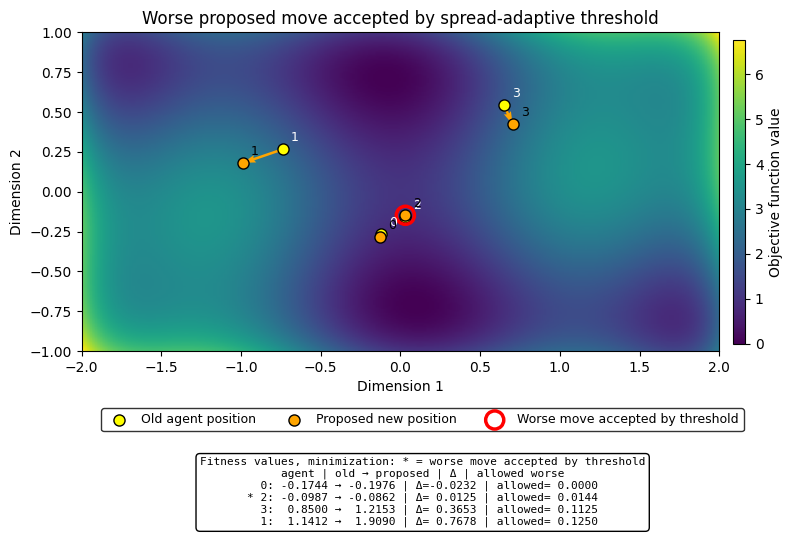

Saved SVG: Figures\it_sia_threshold_random_candidates_clean\candidate_02.svg


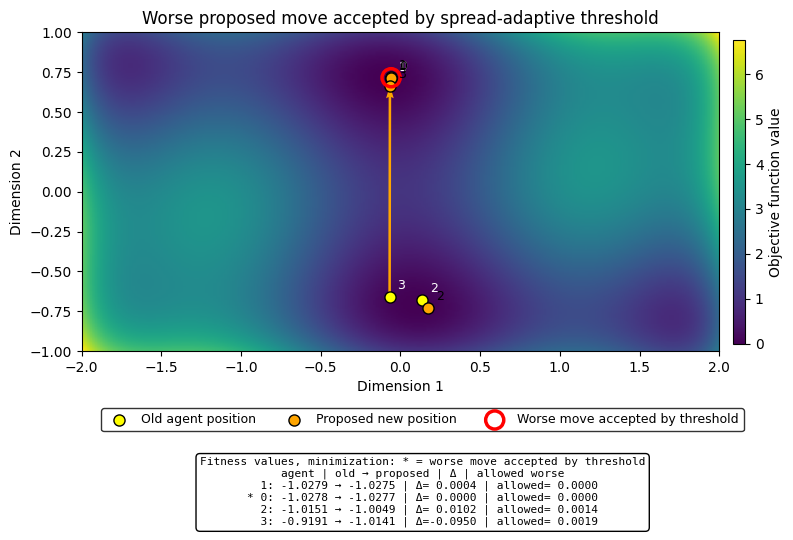

Saved SVG: Figures\it_sia_threshold_random_candidates_clean\candidate_03.svg


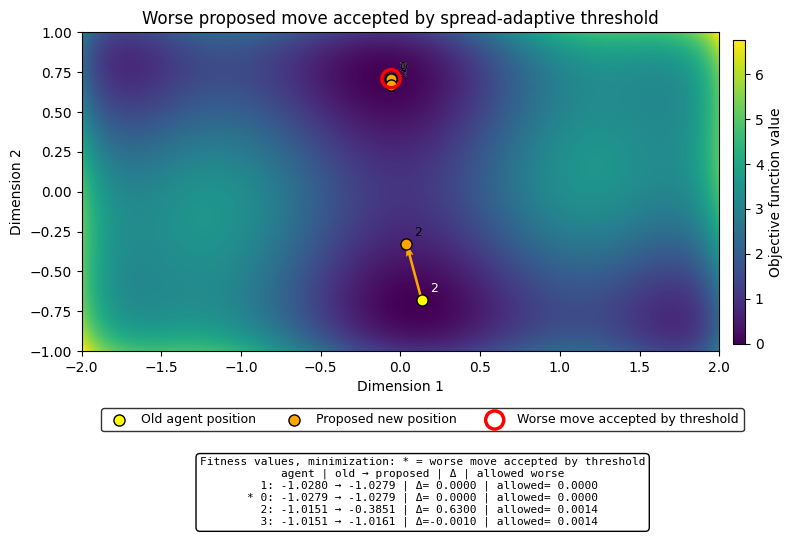

Saved SVG: Figures\it_sia_threshold_random_candidates_clean\candidate_04.svg


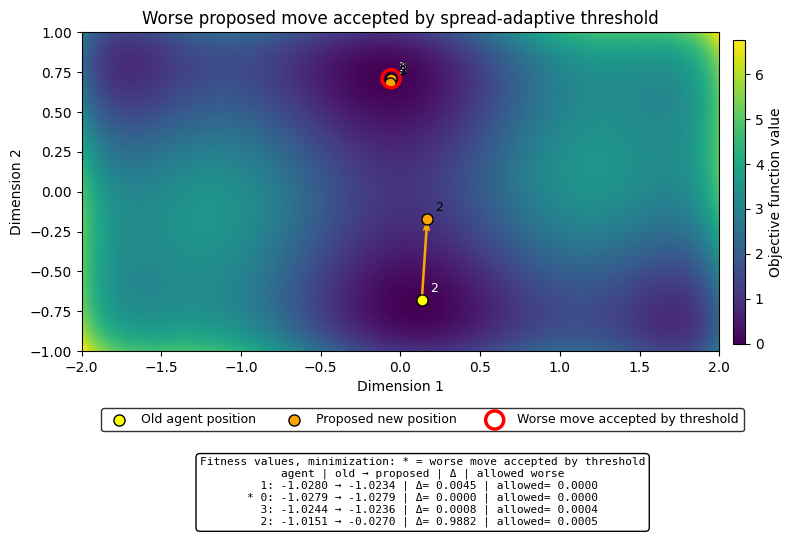

Saved SVG: Figures\it_sia_threshold_random_candidates_clean\candidate_05.svg


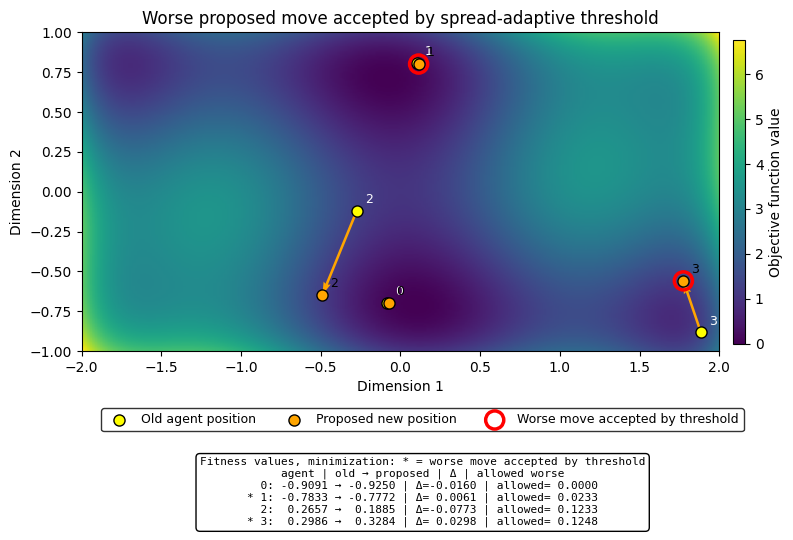

Saved SVG: Figures\it_sia_threshold_random_candidates_clean\candidate_06.svg


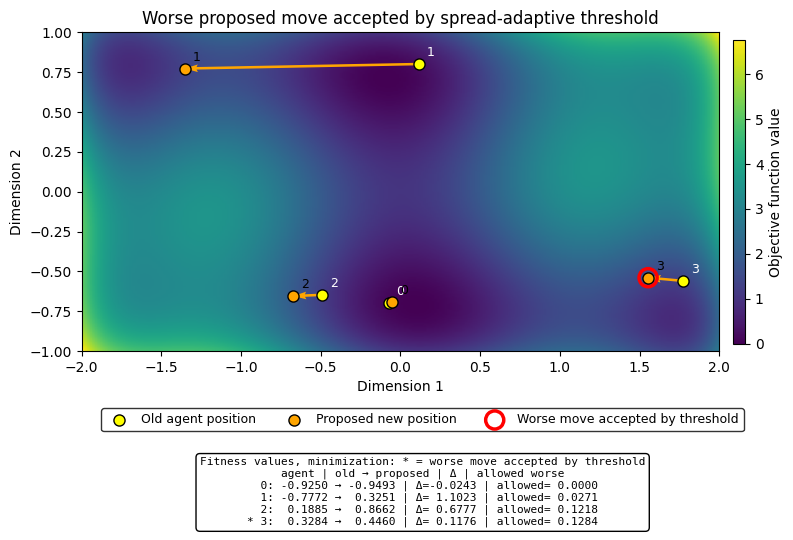

Saved SVG: Figures\it_sia_threshold_random_candidates_clean\candidate_07.svg


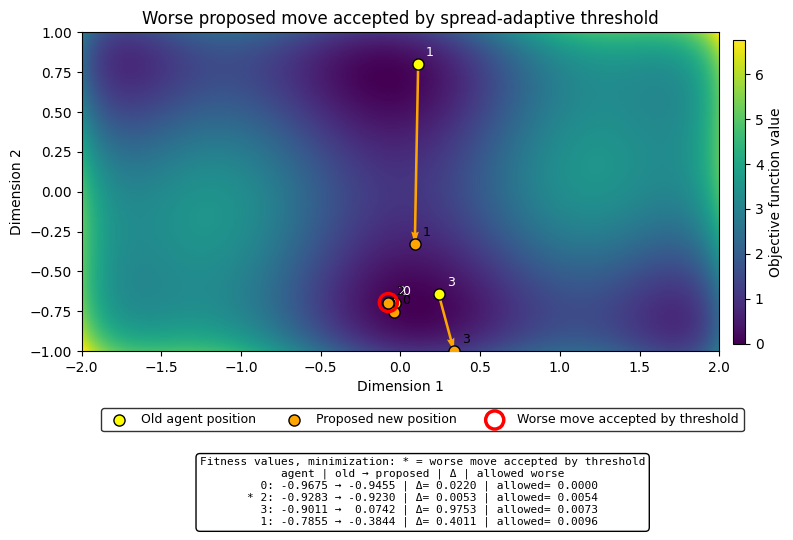

Saved SVG: Figures\it_sia_threshold_random_candidates_clean\candidate_08.svg


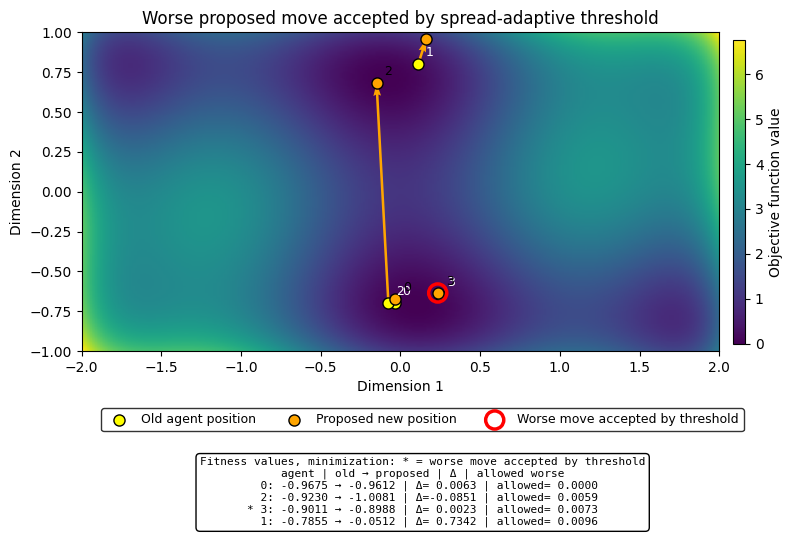

Saved SVG: Figures\it_sia_threshold_random_candidates_clean\candidate_09.svg


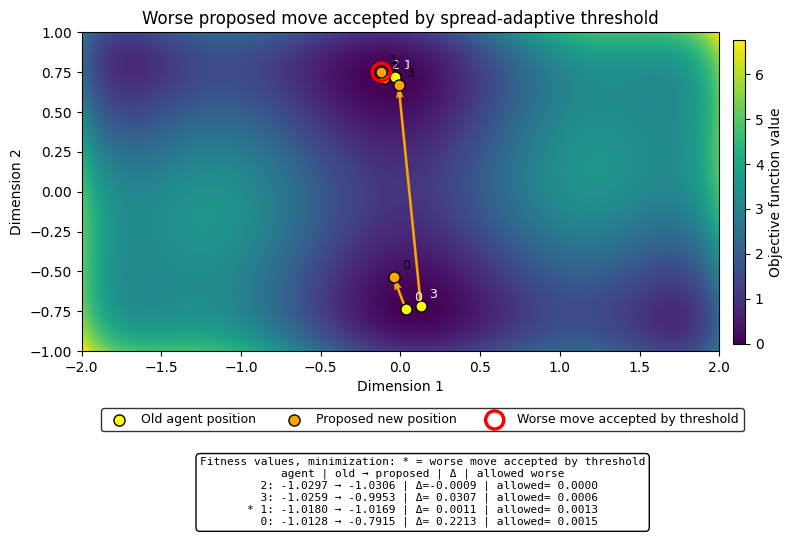

Saved SVG: Figures\it_sia_threshold_random_candidates_clean\candidate_10.svg


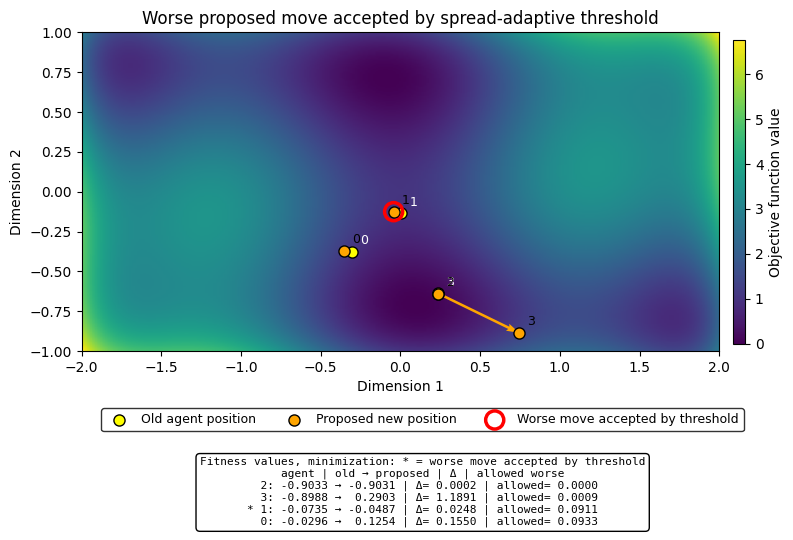

,candidate_id,seed,iteration,accepted_worse_agent_ids,accepted_worse_count,max_accepted_worsening_delta,max_allowed_worse_for_accepted,fitness_spread,svg_file
0,1,1,5,[2],1,1.252319e-02,0.014403,0.759341,Figures\it_sia_threshold_random_candidates_cle...
1,2,1,40,[0],1,1.561642e-05,0.000025,0.009448,Figures\it_sia_threshold_random_candidates_cle...
2,3,1,45,[0],1,5.960464e-07,0.000005,0.009498,Figures\it_sia_threshold_random_candidates_cle...
3,4,1,50,[0],1,1.311302e-06,0.000005,0.002629,Figures\it_sia_threshold_random_candidates_cle...
4,5,2,4,"[1, 3]",2,2.984020e-02,0.124818,0.802007,Figures\it_sia_threshold_random_candidates_cle...
5,6,2,5,[3],1,1.175712e-01,0.128402,0.819590,Figures\it_sia_threshold_random_candidates_cle...
6,7,2,19,[2],1,5.332530e-03,0.005405,0.049214,Figures\it_sia_threshold_random_candidates_cle...
7,8,2,20,[3],1,2.304673e-03,0.007289,0.049214,Figures\it_sia_threshold_random_candidates_cle...
8,9,2,57,[1],1,1.064539e-03,0.001281,0.008649,Figures\it_sia_threshold_random_candidates_cle...
9,10,3,4,[1],1,2.479928e-02,0.091097,0.615105,Figures\it_sia_threshold_random_candidates_cle...


Saved SVG candidates in: Figures\it_sia_threshold_random_candidates_clean
Saved summary file: Figures\it_sia_threshold_random_candidates_clean\candidate_summary_random_clean.xlsx


In [ ]:
# Settings
NUM_AGENTS = 4
AGENT_TYPE = jnp.int16(0)

TEMP_MIN = 0.05
TEMP_MAX = 1.0
ACCEPTANCE_STRENGTH = 0.20

benchmark_family = "2d"
objective_id = b2d.SIX_HUMP_CLASSIC
dim = None

NUM_EXAMPLES_TO_COLLECT = 10
MAX_SEEDS_TO_SEARCH = 3000
MAX_ITERATIONS_TO_SEARCH = 60

SHOW_FIGURES = True

OUTPUT_DIR = Path("Figures/it_sia_threshold_random_candidates_clean")
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

SUMMARY_PATH = OUTPUT_DIR / "candidate_summary_random_clean.xlsx"


# Safety
required_names = [
    "Forager","get_bounds","make_objective_fn","evaluate_positions",
    "initialize_fitness_in_agents","robust_fitness_scale","fitness_spread_control_ratio",
    "individual_temperature_from_fitness","generate_agent_positions",
    "acceptance_rule_mask","apply_acceptance_update",
]

missing = [name for name in required_names if name not in globals()]

if missing:
    raise NameError(f"Missing required objects/functions: {missing}")


# Objective and bounds
bounds = get_bounds(benchmark_family=benchmark_family,objective_id=objective_id,dim=dim)
objective_fn = make_objective_fn(benchmark_family=benchmark_family,objective_id=objective_id,dim=dim)

lo, hi = bounds[:,0], bounds[:,1]

if bounds.shape[0] != 2:
    raise ValueError("This visualization is only for 2D benchmark functions.")

agent_params = abx_struct.Params(content={"bounds": bounds})

xmin, xmax = float(bounds[0,0]), float(bounds[0,1])
ymin, ymax = float(bounds[1,0]), float(bounds[1,1])


# Heatmap
res = 250

x = jnp.linspace(bounds[0,0],bounds[0,1],res)
y = jnp.linspace(bounds[1,0],bounds[1,1],res)
xg, yg = jnp.meshgrid(x,y)

grid_points = jnp.stack([xg.reshape(-1),yg.reshape(-1)],axis=1)

Z_raw = evaluate_positions(grid_points,objective_fn).reshape(res,res)
Z_raw_np = np.array(Z_raw)

Z_np = Z_raw_np - np.nanmin(Z_raw_np)

objective_vmin = 0.0
objective_vmax = float(np.nanmax(Z_np))


# Random initialization
def create_random_initial_population(seed):
    key = random.PRNGKey(seed)

    ids = jnp.arange(NUM_AGENTS,dtype=jnp.int32)
    active_states = jnp.ones(NUM_AGENTS,dtype=bool)

    key, key_agents = random.split(key)
    subkeys = jax.vmap(lambda i: random.fold_in(key_agents,i))(ids)

    agents = jax.vmap(Forager.create_agent,in_axes=(None,None,0,0,0))(
        AGENT_TYPE,agent_params,ids,active_states,subkeys
    )

    pos = agents.state.content["pos"]
    fit_eval = evaluate_positions(pos,objective_fn)

    agents = initialize_fitness_in_agents(
        agents,fit_eval,set_best=True,set_evals_to=1
    )

    agents, _ = Forager.sort_agents_by_fitness(agents)

    return key,agents


# Candidate search
candidate_snapshots = []

for seed in range(1,MAX_SEEDS_TO_SEARCH + 1):
    if len(candidate_snapshots) >= NUM_EXAMPLES_TO_COLLECT:
        break

    key, agents_dbg = create_random_initial_population(seed)

    fit_init = agents_dbg.state.content["fit"]
    fitness_spread_ref = robust_fitness_scale(fit_init)

    for t0 in range(MAX_ITERATIONS_TO_SEARCH):
        if len(candidate_snapshots) >= NUM_EXAMPLES_TO_COLLECT:
            break

        t_iter = jnp.int32(t0 + 1)

        agents_sorted, _ = Forager.sort_agents_by_fitness(agents_dbg)

        pos_parent = agents_sorted.state.content["pos"]
        fit_parent = agents_sorted.state.content["fit"]
        ids_parent = agents_sorted.id

        # Current spread
        fitness_spread_acceptance_ratio, fitness_spread_acceptance_robust = fitness_spread_control_ratio(
            fit_parent,fitness_spread_ref=fitness_spread_ref
        )

        # Individual temperature
        temp = individual_temperature_from_fitness(
            fit_parent,temp_min=TEMP_MIN,temp_max=TEMP_MAX
        )

        # Proposed offspring
        key, pos_offspring, recruitment_step, social_step = generate_agent_positions(
            key,pos_parent,lo,hi,temp
        )

        fit_offspring = evaluate_positions(pos_offspring,objective_fn)

        # Acceptance
        key, accept, mean_theta = acceptance_rule_mask(
            key,fit_parent=fit_parent,fit_offspring=fit_offspring,
            fitness_spread=fitness_spread_acceptance_robust,temp=temp,
            temp_min=TEMP_MIN,temp_max=TEMP_MAX,
            acceptance_strength=ACCEPTANCE_STRENGTH
        )

        # Per-agent threshold
        dtype = fit_parent.dtype
        eps = jnp.asarray(1e-12,dtype=dtype)

        h_i = (temp - TEMP_MIN) / (TEMP_MAX - TEMP_MIN + eps)
        h_i = jnp.clip(h_i,0.0,1.0)

        theta_i = ACCEPTANCE_STRENGTH * fitness_spread_acceptance_robust * h_i
        delta = fit_offspring - fit_parent

        accepted_worse_by_threshold = (delta > 0.0) & (delta <= theta_i) & accept

        if bool(jnp.any(accepted_worse_by_threshold)):
            candidate_id = len(candidate_snapshots) + 1

            candidate_snapshots.append({
                "candidate_id": candidate_id,
                "seed": seed,
                "iteration": int(t_iter),
                "pos_parent": np.array(pos_parent),
                "pos_offspring": np.array(pos_offspring),
                "fit_parent": np.array(fit_parent),
                "fit_offspring": np.array(fit_offspring),
                "ids_parent": np.array(ids_parent),
                "delta": np.array(delta),
                "theta_i": np.array(theta_i),
                "accept": np.array(accept),
                "accepted_worse_by_threshold": np.array(accepted_worse_by_threshold),
                "fitness_spread": float(fitness_spread_acceptance_robust),
                "mean_theta": float(mean_theta),
            })

        # Continue state
        agents_dbg = apply_acceptance_update(
            agents_sorted,pos_offspring=pos_offspring,
            fit_offspring=fit_offspring,accept=accept
        )

if len(candidate_snapshots) == 0:
    raise RuntimeError(
        "No accepted-worse-threshold examples found. "
        "Increase MAX_SEEDS_TO_SEARCH or MAX_ITERATIONS_TO_SEARCH."
    )

print(f"Collected {len(candidate_snapshots)} candidate examples.")


# Candidate plot
def plot_candidate(snapshot):
    candidate_id = snapshot["candidate_id"]

    P = snapshot["pos_parent"]
    O = snapshot["pos_offspring"]
    d = O - P

    ids_np = snapshot["ids_parent"]
    fit_parent_np = snapshot["fit_parent"]
    fit_offspring_np = snapshot["fit_offspring"]
    delta_np = snapshot["delta"]
    theta_np = snapshot["theta_i"]
    accepted_worse_np = snapshot["accepted_worse_by_threshold"]

    # Figure layout
    fig = plt.figure(figsize=(8.8,6.8))
    gs = fig.add_gridspec(nrows=2,ncols=1,height_ratios=[4.2,1.45],hspace=0.10)

    ax = fig.add_subplot(gs[0])
    info_ax = fig.add_subplot(gs[1])
    info_ax.axis("off")

    # Heatmap
    heat_map = ax.imshow(
        Z_np,extent=[xmin,xmax,ymin,ymax],origin="lower",aspect="equal",
        cmap="viridis",vmin=objective_vmin,vmax=objective_vmax
    )

    cbar = fig.colorbar(heat_map,ax=ax,pad=0.02,shrink=0.82,fraction=0.045,aspect=25)
    cbar.set_label("Objective function value")

    # Agent positions
    old_scatter = ax.scatter(
        P[:,0],P[:,1],s=64,color="yellow",edgecolors="black",
        linewidths=1.0,label="Old agent position",zorder=5
    )

    new_scatter = ax.scatter(
        O[:,0],O[:,1],s=64,color="orange",edgecolors="black",
        linewidths=1.0,label="Proposed new position",zorder=6
    )

    # Movement arrows
    ax.quiver(
        P[:,0],P[:,1],d[:,0],d[:,1],angles="xy",scale_units="xy",
        scale=1,color="orange",width=0.004,zorder=4
    )

    # Accepted worse positions
    worse_highlight = None

    if np.any(accepted_worse_np):
        worse_highlight = ax.scatter(
            O[accepted_worse_np,0],O[accepted_worse_np,1],s=170,
            facecolors="none",edgecolors="red",linewidths=2.5,
            label="Worse move accepted by threshold",zorder=7
        )

    # Parent labels
    for i in range(P.shape[0]):
        ax.text(
            float(P[i,0]) + 0.05,float(P[i,1]) + 0.05,str(int(ids_np[i])),
            fontsize=9,color="white",zorder=9,clip_on=True
        )

    # Offspring labels
    for i in range(O.shape[0]):
        ax.text(
            float(O[i,0]) + 0.05,float(O[i,1]) + 0.05,str(int(ids_np[i])),
            fontsize=9,color="black",zorder=9,clip_on=True
        )

    # Plot formatting
    ax.set_xlim(xmin,xmax)
    ax.set_ylim(ymin,ymax)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.set_title("Worse proposed move accepted by spread-adaptive threshold")
    ax.set_aspect("equal",adjustable="box")
    ax.grid(False)

    # Legend
    legend_handles = [old_scatter,new_scatter]
    legend_labels = ["Old agent position","Proposed new position"]

    if worse_highlight is not None:
        legend_handles.append(worse_highlight)
        legend_labels.append("Worse move accepted by threshold")

    info_ax.legend(
        handles=legend_handles,labels=legend_labels,loc="upper center",
        bbox_to_anchor=(0.5,1.00),ncol=len(legend_handles),frameon=True,
        facecolor="white",edgecolor="black",fontsize=9
    )

    # Fitness box
    fitness_lines = [
        "Fitness values, minimization: * = worse move accepted by threshold",
        "agent | old → proposed | Δ | allowed worse",
    ]

    for i in range(len(ids_np)):
        old_fit = float(fit_parent_np[i])
        new_fit = float(fit_offspring_np[i])
        delta = float(delta_np[i])
        allowed = float(theta_np[i])

        marker = "*" if bool(accepted_worse_np[i]) else " "

        fitness_lines.append(
            f"{marker}{int(ids_np[i]):>2}: "
            f"{old_fit: .4f} → {new_fit: .4f} | "
            f"Δ={delta: .4f} | allowed={allowed: .4f}"
        )

    fitness_text = "\n".join(fitness_lines)

    info_ax.text(
        0.5,0.02,fitness_text,ha="center",va="bottom",fontsize=8,
        family="monospace",transform=info_ax.transAxes,
        bbox=dict(facecolor="white",edgecolor="black",boxstyle="round,pad=0.35")
    )

    # Save SVG
    output_path = OUTPUT_DIR / f"candidate_{candidate_id:02d}.svg"

    fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.08)
    print(f"Saved SVG: {output_path}")

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)

    return output_path


# Save candidates
summary_rows = []

for snapshot in candidate_snapshots:
    output_path = plot_candidate(snapshot)

    accepted_worse_mask = snapshot["accepted_worse_by_threshold"]
    ids_np = snapshot["ids_parent"]
    delta_np = snapshot["delta"]
    theta_np = snapshot["theta_i"]

    accepted_ids = ids_np[accepted_worse_mask].astype(int).tolist()
    accepted_deltas = delta_np[accepted_worse_mask]
    accepted_allowed = theta_np[accepted_worse_mask]

    summary_rows.append({
        "candidate_id": snapshot["candidate_id"],
        "seed": snapshot["seed"],
        "iteration": snapshot["iteration"],
        "accepted_worse_agent_ids": accepted_ids,
        "accepted_worse_count": int(np.sum(accepted_worse_mask)),
        "max_accepted_worsening_delta": float(np.max(accepted_deltas)),
        "max_allowed_worse_for_accepted": float(np.max(accepted_allowed)),
        "fitness_spread": snapshot["fitness_spread"],
        "svg_file": str(output_path),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_excel(SUMMARY_PATH,index=False)

display(summary_df)

print(f"Saved SVG candidates in: {OUTPUT_DIR}")
print(f"Saved summary file: {SUMMARY_PATH}")

# Alpha tunning

In [ ]:
# Settings
seeds = list(range(1,6))

alpha_grid = [0.0,0.25,0.50,0.75,1.00,1.50,2.00]

excel_path = "per_agent_time_independent_spread_acceptance_alpha_pilot.xlsx"

dim = 30
T = 10000
num_agents = 30
temp_min = 0.05
temp_max = 1.0


# Alpha ranking
def build_alpha_ranking(alpha_summary_df,metric_col="Error_Median"):
    """Build comparison tables across alpha values."""
    df = alpha_summary_df.copy()

    if metric_col not in df.columns:
        raise ValueError(f"Column {metric_col} not found in alpha_summary_df.")

    # Function-level ranks
    df["rank_within_function"] = df.groupby("cec_func_num")[metric_col].rank(method="average",ascending=True)

    # Best alpha per function
    best_per_function = (
        df.sort_values(["cec_func_num",metric_col])
        .groupby("cec_func_num",as_index=False).first()
    )

    best_per_function = best_per_function[
        [
            "cec_func_num","objective_name","alpha",metric_col,"Mean","Median",
            "Mean_Worse_Acceptance_Rate","Final_Worse_Acceptance_Rate",
            "Mean_Acceptance_Tolerance","Final_Acceptance_Tolerance",
        ]
    ].rename(columns={"alpha": "best_alpha",metric_col: f"best_{metric_col}"})

    # Overall alpha performance
    alpha_rank = (
        df.groupby("alpha",as_index=False)
        .agg(
            average_rank=("rank_within_function","mean"),
            median_rank=("rank_within_function","median"),
            function_wins=("rank_within_function",lambda x: int(np.sum(x == 1.0))),
            mean_error_median=(metric_col,"mean"),
            median_error_median=(metric_col,"median"),
            max_error_median=(metric_col,"max"),
            mean_worse_acceptance_rate=("Mean_Worse_Acceptance_Rate","mean"),
            final_worse_acceptance_rate=("Final_Worse_Acceptance_Rate","mean"),
            mean_acceptance_tolerance=("Mean_Acceptance_Tolerance","mean"),
            final_acceptance_tolerance=("Final_Acceptance_Tolerance","mean"),
        )
        .sort_values(["average_rank","median_rank","max_error_median"])
        .reset_index(drop=True)
    )

    # Regret
    best_metric_by_function = df.groupby("cec_func_num")[metric_col].transform("min")

    df["regret_vs_best_alpha"] = df[metric_col] - best_metric_by_function
    df["ratio_vs_best_alpha"] = df[metric_col] / np.maximum(best_metric_by_function,1e-12)
    df["log10_ratio_vs_best_alpha"] = (
        np.log10(np.maximum(df[metric_col],1e-12))
        - np.log10(np.maximum(best_metric_by_function,1e-12))
    )

    alpha_regret = (
        df.groupby("alpha",as_index=False)
        .agg(
            mean_log10_regret=("log10_ratio_vs_best_alpha","mean"),
            median_ratio_vs_best=("ratio_vs_best_alpha","median"),
            worst_ratio_vs_best=("ratio_vs_best_alpha","max"),
        )
    )

    alpha_rank = alpha_rank.merge(alpha_regret,on="alpha",how="left")
    alpha_rank = alpha_rank.sort_values(
        ["average_rank","mean_log10_regret","worst_ratio_vs_best"]
    ).reset_index(drop=True)

    return df,alpha_rank,best_per_function


# Excel export
def save_alpha_sweep_excel(*,excel_path,alpha_runs_df,alpha_summary_df,alpha_detailed_df,alpha_rank_df,best_per_function_df,config_df):
    """Save current pilot results to Excel."""
    with pd.ExcelWriter(excel_path,engine="openpyxl",mode="w") as writer:
        alpha_summary_df.to_excel(writer,sheet_name="summary_all_alpha",index=False)
        alpha_runs_df.to_excel(writer,sheet_name="raw_all_alpha",index=False)
        alpha_detailed_df.to_excel(writer,sheet_name="detailed_with_ranks",index=False)
        alpha_rank_df.to_excel(writer,sheet_name="alpha_ranking",index=False)
        best_per_function_df.to_excel(writer,sheet_name="best_alpha_per_function",index=False)
        config_df.to_excel(writer,sheet_name="config",index=False)

    print(f"Saved Excel file: {excel_path}")


# Pilot sweep
all_alpha_runs = []
all_alpha_summaries = []

for alpha in alpha_grid:
    print("\n" + "=" * 100)
    print(f"Running alpha = {alpha}")
    print("=" * 100)

    per_run_df, summary_df = run_benchmark_suite(
        benchmark_family="cec",dim=dim,T=T,num_agents=num_agents,seeds=seeds,
        objective_ids=selected_objective_ids,save_csv_path=None,temp_min=temp_min,
        temp_max=temp_max,acceptance_strength=alpha
    )

    per_run_df = per_run_df.copy()
    summary_df = summary_df.copy()

    per_run_df["alpha"] = alpha
    summary_df["alpha"] = alpha

    all_alpha_runs.append(per_run_df)
    all_alpha_summaries.append(summary_df)

    # Partial results
    alpha_runs_partial_df = pd.concat(all_alpha_runs,ignore_index=True)
    alpha_summary_partial_df = pd.concat(all_alpha_summaries,ignore_index=True)

    alpha_detailed_partial_df, alpha_rank_partial_df, best_per_function_partial_df = build_alpha_ranking(
        alpha_summary_partial_df,metric_col="Error_Median"
    )

    config_partial_df = pd.DataFrame([{
        "experiment": "time_independent_spread_acceptance_alpha_pilot2",
        "dim": dim,
        "T": T,
        "num_agents": num_agents,
        "n_seeds": len(seeds),
        "seeds": str(seeds),
        "alpha_grid": str(alpha_grid),
        "completed_alpha_values": str(sorted(alpha_summary_partial_df["alpha"].unique().tolist())),
        "temp_min": temp_min,
        "temp_max": temp_max,
        "objective_ids": str(selected_objective_ids),
        "comparison_metric": "Error_Median",
    }])

    save_alpha_sweep_excel(
        excel_path=excel_path,alpha_runs_df=alpha_runs_partial_df,
        alpha_summary_df=alpha_summary_partial_df,alpha_detailed_df=alpha_detailed_partial_df,
        alpha_rank_df=alpha_rank_partial_df,best_per_function_df=best_per_function_partial_df,
        config_df=config_partial_df
    )


# Final results
alpha_runs_df = pd.concat(all_alpha_runs,ignore_index=True)
alpha_summary_df = pd.concat(all_alpha_summaries,ignore_index=True)

alpha_detailed_df, alpha_rank_df, best_per_function_df = build_alpha_ranking(
    alpha_summary_df,metric_col="Error_Median"
)

config_df = pd.DataFrame([{
    "experiment": "time_independent_spread_acceptance_alpha_pilot",
    "dim": dim,
    "T": T,
    "num_agents": num_agents,
    "n_seeds": len(seeds),
    "seeds": str(seeds),
    "alpha_grid": str(alpha_grid),
    "temp_min": temp_min,
    "temp_max": temp_max,
    "objective_ids": str(selected_objective_ids),
    "comparison_metric": "Error_Median",
}])

save_alpha_sweep_excel(
    excel_path=excel_path,alpha_runs_df=alpha_runs_df,alpha_summary_df=alpha_summary_df,
    alpha_detailed_df=alpha_detailed_df,alpha_rank_df=alpha_rank_df,
    best_per_function_df=best_per_function_df,config_df=config_df
)

display(alpha_rank_df)
display(best_per_function_df)
display(alpha_summary_df)

In [ ]:
# Settings
seeds = list(range(1,31))
acceptance_strength_values = [0.20,0.25,0.30,0.35]

excel_path = "per_agent_spread_acceptance_NO_Q_alpha_tuning_30seeds_summary.xlsx"

dim = 30
T = 10000
num_agents = 30
temp_min = 0.05
temp_max = 1.0


# File tags
def alpha_to_tag(alpha):
    return f"{float(alpha):.2f}".replace(".","p")


def objective_to_tag(objective_id):
    return str(objective_id).replace(" ","_").replace("/","_").replace("\\","_")


# Output folders
output_root = Path("alpha_tuning_no_q_parts")
summary_parts_dir = output_root / "summary_parts"
per_run_parts_dir = output_root / "per_run_parts"

summary_parts_dir.mkdir(parents=True,exist_ok=True)
per_run_parts_dir.mkdir(parents=True,exist_ok=True)


# Alpha ranking
def build_acceptance_strength_ranking(summary_all_df,metric_col="Error_Median"):
    """Build ranking tables across acceptance-strength values."""
    df = summary_all_df.copy()

    if metric_col not in df.columns:
        raise ValueError(f"Column '{metric_col}' not found in summary_all_df.")

    if "acceptance_strength" not in df.columns:
        raise ValueError("Column 'acceptance_strength' not found in summary_all_df.")

    df["rank_within_function"] = df.groupby("cec_func_num")[metric_col].rank(method="average",ascending=True)

    best_per_function_df = (
        df.sort_values(["cec_func_num",metric_col])
        .groupby("cec_func_num",as_index=False).first()
    )

    keep_cols = [
        "cec_func_num","objective_name","acceptance_strength",metric_col,
        "Mean","Median","SD","Error_Mean","Error_SD","Error_Best","Error_Median","Error_Worst",
        "Mean_Worse_Acceptance_Rate","Final_Worse_Acceptance_Rate",
        "Mean_Acceptance_Tolerance","Final_Acceptance_Tolerance",
    ]

    keep_cols = [c for c in keep_cols if c in best_per_function_df.columns]

    best_per_function_df = best_per_function_df[keep_cols].rename(
        columns={"acceptance_strength": "best_acceptance_strength",metric_col: f"best_{metric_col}"}
    )

    best_metric_by_function = df.groupby("cec_func_num")[metric_col].transform("min")

    df["regret_vs_best_acceptance_strength"] = df[metric_col] - best_metric_by_function
    df["ratio_vs_best_acceptance_strength"] = df[metric_col] / np.maximum(best_metric_by_function,1e-12)

    df["log10_ratio_vs_best_acceptance_strength"] = (
        np.log10(np.maximum(df[metric_col],1e-12))
        - np.log10(np.maximum(best_metric_by_function,1e-12))
    )

    ranking_df = (
        df.groupby("acceptance_strength",as_index=False)
        .agg(
            average_rank=("rank_within_function","mean"),
            median_rank=("rank_within_function","median"),
            function_wins=("rank_within_function",lambda x: int(np.sum(x == 1.0))),
            mean_error_median=(metric_col,"mean"),
            median_error_median=(metric_col,"median"),
            max_error_median=(metric_col,"max"),
            mean_ratio_vs_best=("ratio_vs_best_acceptance_strength","mean"),
            median_ratio_vs_best=("ratio_vs_best_acceptance_strength","median"),
            worst_ratio_vs_best=("ratio_vs_best_acceptance_strength","max"),
            mean_log10_ratio_vs_best=("log10_ratio_vs_best_acceptance_strength","mean"),
        )
        .sort_values(
            ["average_rank","mean_log10_ratio_vs_best","worst_ratio_vs_best"],
            ascending=[True,True,True]
        )
        .reset_index(drop=True)
    )

    ranking_df["overall_rank"] = np.arange(1,len(ranking_df) + 1)

    return df,ranking_df,best_per_function_df


# Excel export
def save_alpha_tuning_summary_excel(*,excel_path,summary_all_df,detailed_ranking_df,acceptance_ranking_df,best_per_function_df,per_run_index_df,config_df):
    """Save compact alpha-tuning results to Excel."""
    def _write(path):
        with pd.ExcelWriter(path,engine="openpyxl",mode="w") as writer:
            acceptance_ranking_df.to_excel(writer,sheet_name="acceptance_ranking",index=False)
            best_per_function_df.to_excel(writer,sheet_name="best_per_function",index=False)
            detailed_ranking_df.to_excel(writer,sheet_name="detailed_ranking",index=False)
            summary_all_df.to_excel(writer,sheet_name="summary_all",index=False)
            per_run_index_df.to_excel(writer,sheet_name="per_run_file_index",index=False)
            config_df.to_excel(writer,sheet_name="config",index=False)

    try:
        _write(excel_path)
        print(f"Saved compact summary Excel: {excel_path}")
        return excel_path

    except PermissionError:
        p = Path(excel_path)
        backup_path = p.with_name(f"{p.stem}_backup_{datetime.now().strftime('%Y%m%d_%H%M%S')}{p.suffix}")
        _write(backup_path)
        print("Original Excel file was locked/open.")
        print(f"Saved backup instead to: {backup_path}")
        return str(backup_path)


# Master tables
def build_and_save_master_tables():
    summary_files = sorted(summary_parts_dir.glob("summary_alpha_*.csv"))

    if len(summary_files) == 0:
        print("No summary files found yet.")
        return None

    summary_all_df = pd.concat([pd.read_csv(path) for path in summary_files],ignore_index=True)

    duplicate_cols = [
        c for c in ["acceptance_strength","objective_id","cec_func_num"]
        if c in summary_all_df.columns
    ]

    if duplicate_cols:
        summary_all_df = summary_all_df.drop_duplicates(subset=duplicate_cols,keep="last").reset_index(drop=True)

    detailed_ranking_df, acceptance_ranking_df, best_per_function_df = build_acceptance_strength_ranking(
        summary_all_df,metric_col="Error_Median"
    )

    per_run_index_files = sorted(output_root.glob("per_run_index_*.csv"))

    if per_run_index_files:
        per_run_index_df = pd.concat(
            [pd.read_csv(path) for path in per_run_index_files],ignore_index=True
        ).drop_duplicates()
    else:
        per_run_index_df = pd.DataFrame()

    config_df = pd.DataFrame([{
        "experiment": "no_q_spread_acceptance_alpha_tuning",
        "benchmark_family": "cec",
        "dim": dim,
        "T": T,
        "num_agents": num_agents,
        "n_seeds": len(seeds),
        "seeds": str(seeds),
        "objective_ids": str(selected_objective_ids),
        "temp_min": temp_min,
        "temp_max": temp_max,
        "acceptance_strength_values": str(acceptance_strength_values),
        "completed_acceptance_strength_values": str(sorted(summary_all_df["acceptance_strength"].unique().tolist())),
        "completed_cec_func_nums": str(
            sorted(summary_all_df["cec_func_num"].unique().tolist())
            if "cec_func_num" in summary_all_df.columns else []
        ),
        "comparison_metric": "Error_Median",
        "note": "q term removed. Tuning alpha for theta_i = alpha * sigma_f * h_i.",
    }])

    final_excel = save_alpha_tuning_summary_excel(
        excel_path=excel_path,summary_all_df=summary_all_df,detailed_ranking_df=detailed_ranking_df,
        acceptance_ranking_df=acceptance_ranking_df,best_per_function_df=best_per_function_df,
        per_run_index_df=per_run_index_df,config_df=config_df
    )

    return {
        "summary_all": summary_all_df,
        "detailed_ranking": detailed_ranking_df,
        "acceptance_ranking": acceptance_ranking_df,
        "best_per_function": best_per_function_df,
        "per_run_index": per_run_index_df,
        "excel_path": final_excel,
    }


# Alpha tuning
for acceptance_strength in acceptance_strength_values:
    alpha_tag = alpha_to_tag(acceptance_strength)

    for objective_idx, objective_id in enumerate(selected_objective_ids,start=1):
        obj_tag = objective_to_tag(objective_id)

        summary_file = summary_parts_dir / f"summary_alpha_{alpha_tag}_objective_{objective_idx}_{obj_tag}.csv"
        per_run_file = per_run_parts_dir / f"per_run_alpha_{alpha_tag}_objective_{objective_idx}_{obj_tag}.csv"
        per_run_index_file = output_root / f"per_run_index_alpha_{alpha_tag}_objective_{objective_idx}_{obj_tag}.csv"

        # Resume support
        if summary_file.exists() and per_run_file.exists():
            print(f"Skipping completed chunk: alpha={acceptance_strength}, objective_id={objective_id}")
            continue

        print("\n" + "=" * 100)
        print(f"Running alpha={acceptance_strength} | objective {objective_idx}/{len(selected_objective_ids)} | objective_id={objective_id}")
        print("=" * 100)

        per_run_df, summary_df = run_benchmark_suite(
            benchmark_family="cec",dim=dim,T=T,num_agents=num_agents,seeds=seeds,
            objective_ids=[objective_id],save_csv_path=None,temp_min=temp_min,temp_max=temp_max,
            acceptance_strength=acceptance_strength
        )

        per_run_df = per_run_df.copy()
        summary_df = summary_df.copy()

        per_run_df["acceptance_strength"] = acceptance_strength
        summary_df["acceptance_strength"] = acceptance_strength

        per_run_df["objective_id"] = str(objective_id)
        summary_df["objective_id"] = str(objective_id)

        # Save chunk
        per_run_df.to_csv(per_run_file,index=False)
        summary_df.to_csv(summary_file,index=False)

        per_run_index_df = pd.DataFrame([{
            "acceptance_strength": acceptance_strength,
            "objective_id": str(objective_id),
            "objective_idx": objective_idx,
            "per_run_file": str(per_run_file),
            "summary_file": str(summary_file),
        }])

        per_run_index_df.to_csv(per_run_index_file,index=False)

        print(f"Saved per-run chunk: {per_run_file}")
        print(f"Saved summary chunk: {summary_file}")

        current_results = build_and_save_master_tables()

        # Memory cleanup
        del per_run_df
        del summary_df
        del per_run_index_df

        gc.collect()
        jax.clear_caches()


# Final tables
final_results = build_and_save_master_tables()

acceptance_ranking_df = final_results["acceptance_ranking"]
best_per_function_df = final_results["best_per_function"]
summary_all_df = final_results["summary_all"]

display(acceptance_ranking_df)
display(best_per_function_df)
display(summary_all_df)

Deleted old alpha tuning chunks.

Running alpha=0.2 | objective 1/12 | objective_id=1

Running benchmark: CEC Zakharov
Family: cec | dim=30 | T=10000 | N=30 | runs=30
Running cec | CEC Zakharov | seed=1
Running cec | CEC Zakharov | seed=2
Running cec | CEC Zakharov | seed=3
Running cec | CEC Zakharov | seed=4
Running cec | CEC Zakharov | seed=5
Running cec | CEC Zakharov | seed=6
Running cec | CEC Zakharov | seed=7
Running cec | CEC Zakharov | seed=8
Running cec | CEC Zakharov | seed=9
Running cec | CEC Zakharov | seed=10
Running cec | CEC Zakharov | seed=11
Running cec | CEC Zakharov | seed=12
Running cec | CEC Zakharov | seed=13
Running cec | CEC Zakharov | seed=14
Running cec | CEC Zakharov | seed=15
Running cec | CEC Zakharov | seed=16
Running cec | CEC Zakharov | seed=17
Running cec | CEC Zakharov | seed=18
Running cec | CEC Zakharov | seed=19
Running cec | CEC Zakharov | seed=20
Running cec | CEC Zakharov | seed=21
Running cec | CEC Zakharov | seed=22
Running cec | CEC Zakharov |

,acceptance_strength,average_rank,median_rank,function_wins,mean_error_median,median_error_median,max_error_median,mean_ratio_vs_best,median_ratio_vs_best,worst_ratio_vs_best,mean_log10_ratio_vs_best,overall_rank
0,0.25,2.416667,2.0,2,867.150570,205.558304,7652.238770,1.382965,1.009338,5.084666,0.075260,1
1,0.30,2.500000,2.5,3,1635.751019,216.810852,16868.639648,1.275487,1.023413,3.017097,0.079356,2
2,0.35,2.500000,3.0,4,1459.991611,198.536148,14749.798340,1.513319,1.003774,5.345184,0.101955,3
3,0.20,2.583333,2.5,3,710.611265,200.667068,5591.017090,1.209274,1.021324,2.596844,0.064084,4


,cec_func_num,objective_name,best_acceptance_strength,best_Error_Median,Mean,Median,SD,Error_Mean,Error_SD,Error_Best,best_Error_Median,Error_Worst,Mean_Worse_Acceptance_Rate,Final_Worse_Acceptance_Rate,Mean_Acceptance_Tolerance,Final_Acceptance_Tolerance
0,3,CEC Zakharov,0.25,0.076828,300.463258,300.076828,0.870075,0.463258,0.870075,0.000366,0.076828,3.542938,0.017154,0.017960,3.642419e+07,2.820275e-02
1,5,CEC Rastrigin,0.35,120.170197,623.878888,620.170197,44.293365,123.878888,44.293365,61.448669,120.170197,211.196716,0.006488,0.000000,4.280067e+01,6.941234e+00
2,6,CEC Expanded Scaffer's F6,0.35,11.725098,611.681325,611.725098,0.306265,11.681325,0.306265,11.136963,11.725098,12.172241,0.000854,0.000000,9.349158e-02,9.902767e-02
3,9,CEC Levy,0.35,10.201721,956.938377,910.201721,144.081906,56.938377,144.081906,0.758606,10.201721,773.086548,0.013748,0.009501,7.957736e+01,6.828121e+00
4,11,CEC Hybrid Function 1,0.30,50.964600,1181.831156,1150.964600,71.440110,81.831156,71.440110,22.109985,50.964600,369.505981,0.011547,0.002261,1.883842e+06,4.276405e+00
5,13,CEC Hybrid Function 3,0.20,5591.017090,14337.309456,6891.017090,14267.544367,13037.309456,14267.544367,95.293457,5591.017090,52827.753906,0.023455,0.021354,3.703359e+06,8.012658e+03
6,16,CEC Hybrid Function 6,0.25,779.833740,2389.310763,2379.833740,251.727272,789.310763,251.727272,283.215942,779.833740,1379.478027,0.000648,0.000000,6.517704e+01,6.887404e+01
7,20,CEC Hybrid Function 10,0.20,271.064209,2273.301717,2271.064209,62.306204,273.301717,62.306204,146.672363,271.064209,427.763916,0.000468,0.000000,3.140229e+01,2.766433e+01
8,22,CEC Composition Function 2,0.30,100.001953,2300.229622,2300.001953,0.866390,100.229622,0.866390,100.001221,100.001953,103.418701,0.022676,0.000000,6.696612e+00,9.975563e-08
9,24,CEC Composition Function 4,0.35,485.104980,2880.554810,2885.104980,42.595617,480.554810,42.595617,412.814453,485.104980,563.740967,0.001930,0.001111,7.691683e+00,7.042730e+00


,benchmark_family,objective_id,cec_func_num,objective_name,dim,T,num_agents,n_runs,Mean,SD,...,Final_Worse_Proposal_Rate,Mean_Worse_Acceptance_Rate,Final_Worse_Acceptance_Rate,Mean_Positive_Delta,Final_Mean_Positive_Delta,Mean_Temp,First_Mean_Temp,Final_Mean_Temp,Min_Temp_Seen,Max_Temp_Seen
0,cec,12,24,CEC Composition Function 4,30,10000,30,30,2897.320597,38.997750,...,1.000000,0.000943,0.000000,1.652171e+02,1.717518e+02,0.927327,0.826740,0.921841,0.05,1.000000
1,cec,14,27,CEC Composition Function 7,30,10000,30,30,3174.643628,8.559927,...,0.890000,0.010318,0.003649,2.954280e+02,2.559914e+02,0.679395,0.806532,0.714043,0.05,1.000000
2,cec,15,28,CEC Composition Function 8,30,10000,30,30,3193.698934,16.514507,...,0.733333,0.010434,0.001333,1.506515e+03,1.408256e+03,0.312751,0.746398,0.201682,0.05,1.000000
3,cec,1,3,CEC Zakharov,30,10000,30,30,300.416785,0.945840,...,0.931111,0.014563,0.018232,1.879744e+13,6.613513e+08,0.539437,0.523646,0.553255,0.05,1.000000
4,cec,2,5,CEC Rastrigin,30,10000,30,30,641.864111,48.338453,...,1.000000,0.003140,0.000000,3.079241e+02,1.530754e+02,0.914339,0.783050,0.929497,0.05,1.000000
5,cec,3,6,CEC Expanded Scaffer's F6,30,10000,30,30,611.758114,0.385442,...,0.998889,0.000352,0.000000,1.916356e+00,2.197496e+00,0.891269,0.881335,0.911379,0.05,1.000000
6,cec,4,9,CEC Levy,30,10000,30,30,972.191744,108.009385,...,0.943333,0.005234,0.002384,2.147908e+03,5.621667e+02,0.713828,0.749670,0.647948,0.05,1.000000
7,cec,5,11,CEC Hybrid Function 1,30,10000,30,30,1186.790942,67.681649,...,0.987778,0.007151,0.005872,3.156179e+08,1.340517e+07,0.730756,0.702899,0.779293,0.05,1.000000
8,cec,7,13,CEC Hybrid Function 3,30,10000,30,30,14337.309456,14267.544367,...,0.914444,0.023455,0.021354,1.211784e+09,1.118655e+09,0.503113,0.794660,0.498587,0.05,1.000000
9,cec,8,16,CEC Hybrid Function 6,30,10000,30,30,2544.774259,271.403839,...,1.000000,0.000462,0.000000,2.653672e+03,2.566252e+03,0.916071,0.710111,0.905183,0.05,1.000000


# Convergance analysis data


In [ ]:
def safe_save_convergence_excel(*,excel_path,convergence_all_df,per_run_all_df,config_df,search_range_df=None):
    def _write(path):
        with pd.ExcelWriter(path,engine="openpyxl",mode="w") as writer:
            convergence_all_df.to_excel(writer,sheet_name="convergence_all",index=False)
            per_run_all_df.to_excel(writer,sheet_name="per_run_all",index=False)
            config_df.to_excel(writer,sheet_name="config",index=False)

            if search_range_df is not None:
                search_range_df.to_excel(writer,sheet_name="search_range_by_function",index=False)

    try:
        _write(excel_path)
        print(f"Saved: {excel_path}")
        return excel_path

    except PermissionError:
        p = Path(excel_path)
        backup_path = p.with_name(f"{p.stem}_backup_{datetime.now().strftime('%Y%m%d_%H%M%S')}{p.suffix}")
        _write(backup_path)
        print(f"Excel file was locked. Saved backup to: {backup_path}")
        return str(backup_path)


def get_cec_metadata_safe(objective_id,*,dim,cec_module=None):
    """Recover the CEC function number, name, and known bias."""
    cec_func_num = None
    objective_name = str(objective_id)
    cec_bias = np.nan

    try:
        params = cec_module.get_cec_params(dim=dim)
        cec_func_num = int(params[objective_id]["func_num"])
        cec_bias = float(params[objective_id].get("bias",np.nan))
    except Exception:
        try:
            cec_func_num = int(objective_id)
        except Exception:
            cec_func_num = None

    try:
        objective_name = get_objective_name("cec",objective_id)
    except Exception:
        objective_name = f"CEC {cec_func_num}" if cec_func_num is not None else str(objective_id)

    return cec_func_num,objective_name,cec_bias


def extract_search_range_from_conv_matrix(*,conv_matrix,metric_names,algorithm_label,objective_id,cec_func_num,objective_name,cec_bias,dim,T,num_agents,seeds):
    """Extract the observed CEC error range for one algorithm-function pair."""
    best_idx = metric_names.index("best_fit")
    worst_idx = metric_names.index("worst_fit")

    best_fit_hist = np.asarray(conv_matrix[:,:,best_idx],dtype=float)
    worst_fit_hist = np.asarray(conv_matrix[:,:,worst_idx],dtype=float)

    best_error_hist = best_fit_hist - float(cec_bias)
    worst_error_hist = worst_fit_hist - float(cec_bias)

    search_min_error = float(np.min(best_error_hist))
    search_max_error = float(np.max(worst_error_hist))
    search_range = search_max_error - search_min_error

    return {
        "algorithm": algorithm_label,
        "objective_id": str(objective_id),
        "cec_func_num": cec_func_num,
        "objective_name": objective_name,
        "dim": dim,
        "T": T,
        "num_agents": num_agents,
        "n_seeds": len(seeds),
        "seed_start": min(seeds),
        "seed_end": max(seeds),
        "cec_bias": cec_bias,
        "search_min_error_algorithm": search_min_error,
        "search_max_error_algorithm": search_max_error,
        "search_range_algorithm": search_range,
        "search_min_source": "min over best_fit across seeds and iterations",
        "search_max_source": "max over worst_fit across seeds and iterations",
    }


def run_convergence_suite_for_algorithm(*,algorithm_label,objective_ids,dim,T,num_agents,seeds,excel_path,cec_module=None,run_kwargs=None):
    """Run convergence testing over the selected CEC functions."""
    if run_kwargs is None:
        run_kwargs = {}

    all_conv_summaries = []
    all_per_run_dfs = []
    all_search_range_rows = []

    for objective_id in objective_ids:
        cec_func_num, objective_name, cec_bias = get_cec_metadata_safe(
            objective_id,dim=dim,cec_module=cec_module
        )

        print("\n" + "=" * 100)
        print(f"Algorithm: {algorithm_label}")
        print(f"Function: CEC {cec_func_num} | {objective_name}")
        print("=" * 100)

        conv_matrix, per_run_df, conv_summary_df, metric_names = run_repeated_convergence_experiments(
            benchmark_family="cec",objective_id=objective_id,dim=dim,T=T,
            num_agents=num_agents,seeds=seeds,**run_kwargs
        )

        search_range_row = extract_search_range_from_conv_matrix(
            conv_matrix=conv_matrix,metric_names=metric_names,algorithm_label=algorithm_label,
            objective_id=objective_id,cec_func_num=cec_func_num,objective_name=objective_name,
            cec_bias=cec_bias,dim=dim,T=T,num_agents=num_agents,seeds=seeds
        )

        all_search_range_rows.append(search_range_row)

        conv_summary_df = conv_summary_df.copy()
        per_run_df = per_run_df.copy()

        conv_summary_df.insert(0,"algorithm_label",algorithm_label)
        conv_summary_df.insert(1,"objective_id",str(objective_id))
        conv_summary_df.insert(2,"cec_func_num",cec_func_num)
        conv_summary_df.insert(3,"objective_name",objective_name)

        conv_summary_df["dim"] = dim
        conv_summary_df["T"] = T
        conv_summary_df["num_agents"] = num_agents
        conv_summary_df["n_seeds"] = len(seeds)
        conv_summary_df["cec_bias"] = cec_bias

        for k, v in run_kwargs.items():
            conv_summary_df[k] = v

        per_run_df.insert(0,"algorithm_label",algorithm_label)
        per_run_df["objective_id"] = str(objective_id)
        per_run_df["cec_func_num"] = cec_func_num
        per_run_df["objective_name"] = objective_name

        for k, v in run_kwargs.items():
            per_run_df[k] = v

        all_conv_summaries.append(conv_summary_df)
        all_per_run_dfs.append(per_run_df)

        # Partial save
        convergence_partial_df = pd.concat(all_conv_summaries,ignore_index=True)
        per_run_partial_df = pd.concat(all_per_run_dfs,ignore_index=True)
        search_range_partial_df = pd.DataFrame(all_search_range_rows)

        config_partial_df = pd.DataFrame([{
            "algorithm_label": algorithm_label,
            "dim": dim,
            "T": T,
            "num_agents": num_agents,
            "n_seeds": len(seeds),
            "seeds": str(seeds),
            "objective_ids": str(objective_ids),
            "completed_cec_functions": str(sorted(convergence_partial_df["cec_func_num"].dropna().unique().tolist())),
            "run_kwargs": str(run_kwargs),
        }])

        excel_path = safe_save_convergence_excel(
            excel_path=excel_path,convergence_all_df=convergence_partial_df,
            per_run_all_df=per_run_partial_df,config_df=config_partial_df,
            search_range_df=search_range_partial_df
        )

    convergence_all_df = pd.concat(all_conv_summaries,ignore_index=True)
    per_run_all_df = pd.concat(all_per_run_dfs,ignore_index=True)
    search_range_df = pd.DataFrame(all_search_range_rows)

    config_df = pd.DataFrame([{
        "algorithm_label": algorithm_label,
        "dim": dim,
        "T": T,
        "num_agents": num_agents,
        "n_seeds": len(seeds),
        "seeds": str(seeds),
        "objective_ids": str(objective_ids),
        "run_kwargs": str(run_kwargs),
    }])

    excel_path = safe_save_convergence_excel(
        excel_path=excel_path,convergence_all_df=convergence_all_df,
        per_run_all_df=per_run_all_df,config_df=config_df,search_range_df=search_range_df
    )

    return convergence_all_df,per_run_all_df,search_range_df

In [13]:
def get_selected_cec_objective_ids(dim=30, exclude_func_nums=None):
    exclude_func_nums = set(exclude_func_nums or [])

    params = bcec.get_cec_params(dim=dim)

    if "get_suite_ids" in globals():
        suite_ids = list(get_suite_ids("cec"))
    elif hasattr(bcec, "get_cec_suite_ids"):
        suite_ids = list(bcec.get_cec_suite_ids())
    else:
        suite_ids = list(params.keys())

    rows = []
    selected_ids = []

    for objective_id in suite_ids:
        cec_func_num = int(params[objective_id]["func_num"])

        try:
            objective_name = get_objective_name("cec", objective_id)
        except Exception:
            objective_name = f"CEC Function {cec_func_num}"

        selected = cec_func_num not in exclude_func_nums

        rows.append({
            "objective_id": objective_id,
            "cec_func_num": cec_func_num,
            "objective_name": objective_name,
            "selected": selected,
        })

        if selected:
            selected_ids.append(objective_id)

    mapping_df = (
        pd.DataFrame(rows)
        .sort_values("cec_func_num")
        .reset_index(drop=True)
    )

    return selected_ids, mapping_df

EXCLUDED_CEC_FUNC_NUMS = {1, 13, 14, 18, 26, 30}


# For T = 100

In [13]:
seeds = list(range(1, 31))
dim = 30
T = 100
num_agents = 30
selected_objective_ids, cec_mapping_df = get_selected_cec_objective_ids(dim=dim, exclude_func_nums=EXCLUDED_CEC_FUNC_NUMS)
objective_ids = selected_objective_ids

conv_sia_df, per_run_sia_df, search_range_sia_df = run_convergence_suite_for_algorithm(
    algorithm_label="IT-SIA-QOS-OFA",
    objective_ids=objective_ids,
    dim=dim,
    T=T,
    num_agents=num_agents,
    seeds=seeds,
    excel_path="convergence_IT_SIA_QOS_OFA_all_usable_cec_100T.xlsx",
    cec_module=bcec,
    run_kwargs={
        "temp_min": 0.05,
        "temp_max": 1.0,
        "acceptance_strength": 0.20,
    },
)

display(search_range_sia_df)

OUTPUT_DIR = Path("analysis_exports")
OUTPUT_DIR.mkdir(exist_ok=True)

search_range_sia_path = OUTPUT_DIR / "search_range_IT_SIA_QOS_OFA.xlsx"
search_range_sia_df.to_excel(search_range_sia_path, index=False)

print(f"Saved IT-SIA-QOS-OFA search-range file to: {search_range_sia_path}")


Algorithm: IT-SIA-QOS-OFA
Function: CEC 3 | CEC Zakharov
Running convergence | cec | CEC Zakharov | seed=1
Running convergence | cec | CEC Zakharov | seed=2
Running convergence | cec | CEC Zakharov | seed=3
Running convergence | cec | CEC Zakharov | seed=4
Running convergence | cec | CEC Zakharov | seed=5
Running convergence | cec | CEC Zakharov | seed=6
Running convergence | cec | CEC Zakharov | seed=7
Running convergence | cec | CEC Zakharov | seed=8
Running convergence | cec | CEC Zakharov | seed=9
Running convergence | cec | CEC Zakharov | seed=10
Running convergence | cec | CEC Zakharov | seed=11
Running convergence | cec | CEC Zakharov | seed=12
Running convergence | cec | CEC Zakharov | seed=13
Running convergence | cec | CEC Zakharov | seed=14
Running convergence | cec | CEC Zakharov | seed=15
Running convergence | cec | CEC Zakharov | seed=16
Running convergence | cec | CEC Zakharov | seed=17
Running convergence | cec | CEC Zakharov | seed=18
Running convergence | cec | CEC Z

C:\Users\kvrgi\AppData\Local\Temp\ipykernel_50416\2892633254.py:238: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_median"] = np.median(values, axis=0)
C:\Users\kvrgi\AppData\Local\Temp\ipykernel_50416\2892633254.py:239: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_q25"] = np.quantile(values, 0.25, axis=0)
C:\Users\kvrgi\AppData\Local\Temp\ipykernel_50416\2892633254.py:240: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor

Saved: convergence_IT_SIA_QOS_OFA_all_usable_cec_100T.xlsx

Algorithm: IT-SIA-QOS-OFA
Function: CEC 5 | CEC Rastrigin
Running convergence | cec | CEC Rastrigin | seed=1
Running convergence | cec | CEC Rastrigin | seed=2
Running convergence | cec | CEC Rastrigin | seed=3
Running convergence | cec | CEC Rastrigin | seed=4
Running convergence | cec | CEC Rastrigin | seed=5
Running convergence | cec | CEC Rastrigin | seed=6
Running convergence | cec | CEC Rastrigin | seed=7
Running convergence | cec | CEC Rastrigin | seed=8
Running convergence | cec | CEC Rastrigin | seed=9
Running convergence | cec | CEC Rastrigin | seed=10
Running convergence | cec | CEC Rastrigin | seed=11
Running convergence | cec | CEC Rastrigin | seed=12
Running convergence | cec | CEC Rastrigin | seed=13
Running convergence | cec | CEC Rastrigin | seed=14
Running convergence | cec | CEC Rastrigin | seed=15
Running convergence | cec | CEC Rastrigin | seed=16
Running convergence | cec | CEC Rastrigin | seed=17
Running

C:\Users\kvrgi\AppData\Local\Temp\ipykernel_50416\2892633254.py:238: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_median"] = np.median(values, axis=0)
C:\Users\kvrgi\AppData\Local\Temp\ipykernel_50416\2892633254.py:239: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_q25"] = np.quantile(values, 0.25, axis=0)
C:\Users\kvrgi\AppData\Local\Temp\ipykernel_50416\2892633254.py:240: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor

Saved: convergence_IT_SIA_QOS_OFA_all_usable_cec_100T.xlsx

Algorithm: IT-SIA-QOS-OFA
Function: CEC 6 | CEC Expanded Scaffer's F6
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=1
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=2
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=3
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=4
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=5
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=6
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=7
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=8
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=9
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=10
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=11
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=12
Running convergence | cec | CEC Expanded Scaffer's F6 | seed=13
Running convergence | cec | CEC Expanded Scaffe

...

Saved: convergence_IT_SIA_QOS_OFA_all_usable_cec_100T.xlsx

Algorithm: IT-SIA-QOS-OFA
Function: CEC 28 | CEC Composition Function 8
Running convergence | cec | CEC Composition Function 8 | seed=1
Running convergence | cec | CEC Composition Function 8 | seed=2
Running convergence | cec | CEC Composition Function 8 | seed=3
Running convergence | cec | CEC Composition Function 8 | seed=4
Running convergence | cec | CEC Composition Function 8 | seed=5
Running convergence | cec | CEC Composition Function 8 | seed=6
Running convergence | cec | CEC Composition Function 8 | seed=7
Running convergence | cec | CEC Composition Function 8 | seed=8
Running convergence | cec | CEC Composition Function 8 | seed=9
Running convergence | cec | CEC Composition Function 8 | seed=10
Running convergence | cec | CEC Composition Function 8 | seed=11
Running convergence | cec | CEC Composition Function 8 | seed=12
Running convergence | cec | CEC Composition Function 8 | seed=13
Running convergence | cec | CEC 

C:\Users\kvrgi\AppData\Local\Temp\ipykernel_50416\2892633254.py:238: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_median"] = np.median(values, axis=0)
C:\Users\kvrgi\AppData\Local\Temp\ipykernel_50416\2892633254.py:239: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_q25"] = np.quantile(values, 0.25, axis=0)
C:\Users\kvrgi\AppData\Local\Temp\ipykernel_50416\2892633254.py:240: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor

Saved: convergence_IT_SIA_QOS_OFA_all_usable_cec_100T.xlsx
Saved: convergence_IT_SIA_QOS_OFA_all_usable_cec_100T.xlsx


,algorithm,objective_id,cec_func_num,objective_name,dim,T,num_agents,n_seeds,seed_start,seed_end,cec_bias,search_min_error_algorithm,search_max_error_algorithm,search_range_algorithm,search_min_source,search_max_source
0,IT-SIA-QOS-OFA,1,3,CEC Zakharov,30,100,30,30,1,30,300.0,72013.875000,5.995408e+13,5.995408e+13,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
1,IT-SIA-QOS-OFA,2,5,CEC Rastrigin,30,100,30,30,1,30,500.0,6228.235840,2.261603e+05,2.199321e+05,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
2,IT-SIA-QOS-OFA,3,6,CEC Expanded Scaffer's F6,30,100,30,30,1,30,600.0,12.838074,1.506769e+01,2.229614e+00,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
3,IT-SIA-QOS-OFA,4,9,CEC Levy,30,100,30,30,1,30,900.0,3791.856934,6.133376e+04,5.754190e+04,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
4,IT-SIA-QOS-OFA,5,11,CEC Hybrid Function 1,30,100,30,30,1,30,1100.0,143026.156250,4.763035e+10,4.763021e+10,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
5,IT-SIA-QOS-OFA,8,16,CEC Hybrid Function 6,30,100,30,30,1,30,1600.0,1186.687744,4.262486e+04,4.143817e+04,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
6,IT-SIA-QOS-OFA,10,20,CEC Hybrid Function 10,30,100,30,30,1,30,2000.0,392.079834,2.874191e+03,2.482111e+03,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
7,IT-SIA-QOS-OFA,11,22,CEC Composition Function 2,30,100,30,30,1,30,2200.0,773.088379,1.298145e+04,1.220836e+04,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
8,IT-SIA-QOS-OFA,12,24,CEC Composition Function 4,30,100,30,30,1,30,2400.0,573.175049,3.521068e+03,2.947893e+03,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
9,IT-SIA-QOS-OFA,14,27,CEC Composition Function 7,30,100,30,30,1,30,2700.0,697.697266,6.393315e+03,5.695618e+03,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations


Saved IT-SIA-QOS-OFA search-range file to: analysis_exports\search_range_IT_SIA_QOS_OFA.xlsx


# For T = 10000

Selected CEC functions:


,objective_id,cec_func_num,objective_name,selected
1,1,3,CEC Zakharov,True
2,2,5,CEC Rastrigin,True
3,3,6,CEC Expanded Scaffer's F6,True
4,4,9,CEC Levy,True
5,5,11,CEC Hybrid Function 1,True
8,8,16,CEC Hybrid Function 6,True
10,10,20,CEC Hybrid Function 10,True
11,11,22,CEC Composition Function 2,True
12,12,24,CEC Composition Function 4,True
14,14,27,CEC Composition Function 7,True



Algorithm: IT-SIA-QOS-OFA
Function: CEC 3 | CEC Zakharov
Running convergence | cec | CEC Zakharov | seed=1
Running convergence | cec | CEC Zakharov | seed=2
Running convergence | cec | CEC Zakharov | seed=3
Running convergence | cec | CEC Zakharov | seed=4
Running convergence | cec | CEC Zakharov | seed=5
Running convergence | cec | CEC Zakharov | seed=6
Running convergence | cec | CEC Zakharov | seed=7
Running convergence | cec | CEC Zakharov | seed=8
Running convergence | cec | CEC Zakharov | seed=9
Running convergence | cec | CEC Zakharov | seed=10
Running convergence | cec | CEC Zakharov | seed=11
Running convergence | cec | CEC Zakharov | seed=12
Running convergence | cec | CEC Zakharov | seed=13
Running convergence | cec | CEC Zakharov | seed=14
Running convergence | cec | CEC Zakharov | seed=15
Running convergence | cec | CEC Zakharov | seed=16
Running convergence | cec | CEC Zakharov | seed=17
Running convergence | cec | CEC Zakharov | seed=18
Running convergence | cec | CEC Z

C:\Users\kvrgi\AppData\Local\Temp\ipykernel_159764\2892633254.py:238: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_median"] = np.median(values, axis=0)
C:\Users\kvrgi\AppData\Local\Temp\ipykernel_159764\2892633254.py:239: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_q25"] = np.quantile(values, 0.25, axis=0)
C:\Users\kvrgi\AppData\Local\Temp\ipykernel_159764\2892633254.py:240: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has p

Saved: analysis_exports\convergence_IT_SIA_QOS_OFA_all_usable_cec.xlsx

Algorithm: IT-SIA-QOS-OFA
Function: CEC 5 | CEC Rastrigin
Running convergence | cec | CEC Rastrigin | seed=1
Running convergence | cec | CEC Rastrigin | seed=2
Running convergence | cec | CEC Rastrigin | seed=3
Running convergence | cec | CEC Rastrigin | seed=4
Running convergence | cec | CEC Rastrigin | seed=5
Running convergence | cec | CEC Rastrigin | seed=6
Running convergence | cec | CEC Rastrigin | seed=7
Running convergence | cec | CEC Rastrigin | seed=8
Running convergence | cec | CEC Rastrigin | seed=9
Running convergence | cec | CEC Rastrigin | seed=10
Running convergence | cec | CEC Rastrigin | seed=11
Running convergence | cec | CEC Rastrigin | seed=12
Running convergence | cec | CEC Rastrigin | seed=13
Running convergence | cec | CEC Rastrigin | seed=14
Running convergence | cec | CEC Rastrigin | seed=15
Running convergence | cec | CEC Rastrigin | seed=16
Running convergence | cec | CEC Rastrigin | see

...

Saved: analysis_exports\convergence_IT_SIA_QOS_OFA_all_usable_cec.xlsx

Algorithm: IT-SIA-QOS-OFA
Function: CEC 27 | CEC Composition Function 7
Running convergence | cec | CEC Composition Function 7 | seed=1
Running convergence | cec | CEC Composition Function 7 | seed=2
Running convergence | cec | CEC Composition Function 7 | seed=3
Running convergence | cec | CEC Composition Function 7 | seed=4
Running convergence | cec | CEC Composition Function 7 | seed=5
Running convergence | cec | CEC Composition Function 7 | seed=6
Running convergence | cec | CEC Composition Function 7 | seed=7
Running convergence | cec | CEC Composition Function 7 | seed=8
Running convergence | cec | CEC Composition Function 7 | seed=9
Running convergence | cec | CEC Composition Function 7 | seed=10
Running convergence | cec | CEC Composition Function 7 | seed=11
Running convergence | cec | CEC Composition Function 7 | seed=12
Running convergence | cec | CEC Composition Function 7 | seed=13
Running convergence 

C:\Users\kvrgi\AppData\Local\Temp\ipykernel_159764\2892633254.py:238: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_median"] = np.median(values, axis=0)
C:\Users\kvrgi\AppData\Local\Temp\ipykernel_159764\2892633254.py:239: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_q25"] = np.quantile(values, 0.25, axis=0)
C:\Users\kvrgi\AppData\Local\Temp\ipykernel_159764\2892633254.py:240: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has p

Saved: analysis_exports\convergence_IT_SIA_QOS_OFA_all_usable_cec.xlsx

Algorithm: IT-SIA-QOS-OFA
Function: CEC 28 | CEC Composition Function 8
Running convergence | cec | CEC Composition Function 8 | seed=1
Running convergence | cec | CEC Composition Function 8 | seed=2
Running convergence | cec | CEC Composition Function 8 | seed=3
Running convergence | cec | CEC Composition Function 8 | seed=4
Running convergence | cec | CEC Composition Function 8 | seed=5
Running convergence | cec | CEC Composition Function 8 | seed=6
Running convergence | cec | CEC Composition Function 8 | seed=7
Running convergence | cec | CEC Composition Function 8 | seed=8
Running convergence | cec | CEC Composition Function 8 | seed=9
Running convergence | cec | CEC Composition Function 8 | seed=10
Running convergence | cec | CEC Composition Function 8 | seed=11
Running convergence | cec | CEC Composition Function 8 | seed=12
Running convergence | cec | CEC Composition Function 8 | seed=13
Running convergence 

C:\Users\kvrgi\AppData\Local\Temp\ipykernel_159764\2892633254.py:238: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_median"] = np.median(values, axis=0)
C:\Users\kvrgi\AppData\Local\Temp\ipykernel_159764\2892633254.py:239: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_q25"] = np.quantile(values, 0.25, axis=0)
C:\Users\kvrgi\AppData\Local\Temp\ipykernel_159764\2892633254.py:240: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has p

Saved: analysis_exports\convergence_IT_SIA_QOS_OFA_all_usable_cec.xlsx
Saved: analysis_exports\convergence_IT_SIA_QOS_OFA_all_usable_cec.xlsx
Saved convergence workbook: analysis_exports\convergence_IT_SIA_QOS_OFA_all_usable_cec.xlsx
Accepted worse count columns:
['accepted_worse_count_mean', 'accepted_worse_count_std', 'accepted_worse_count_median', 'accepted_worse_count_q25', 'accepted_worse_count_q75']
Maximum iteration: 10000
Y column: accepted_worse_count_median
SVG downsampling: every 10 iterations


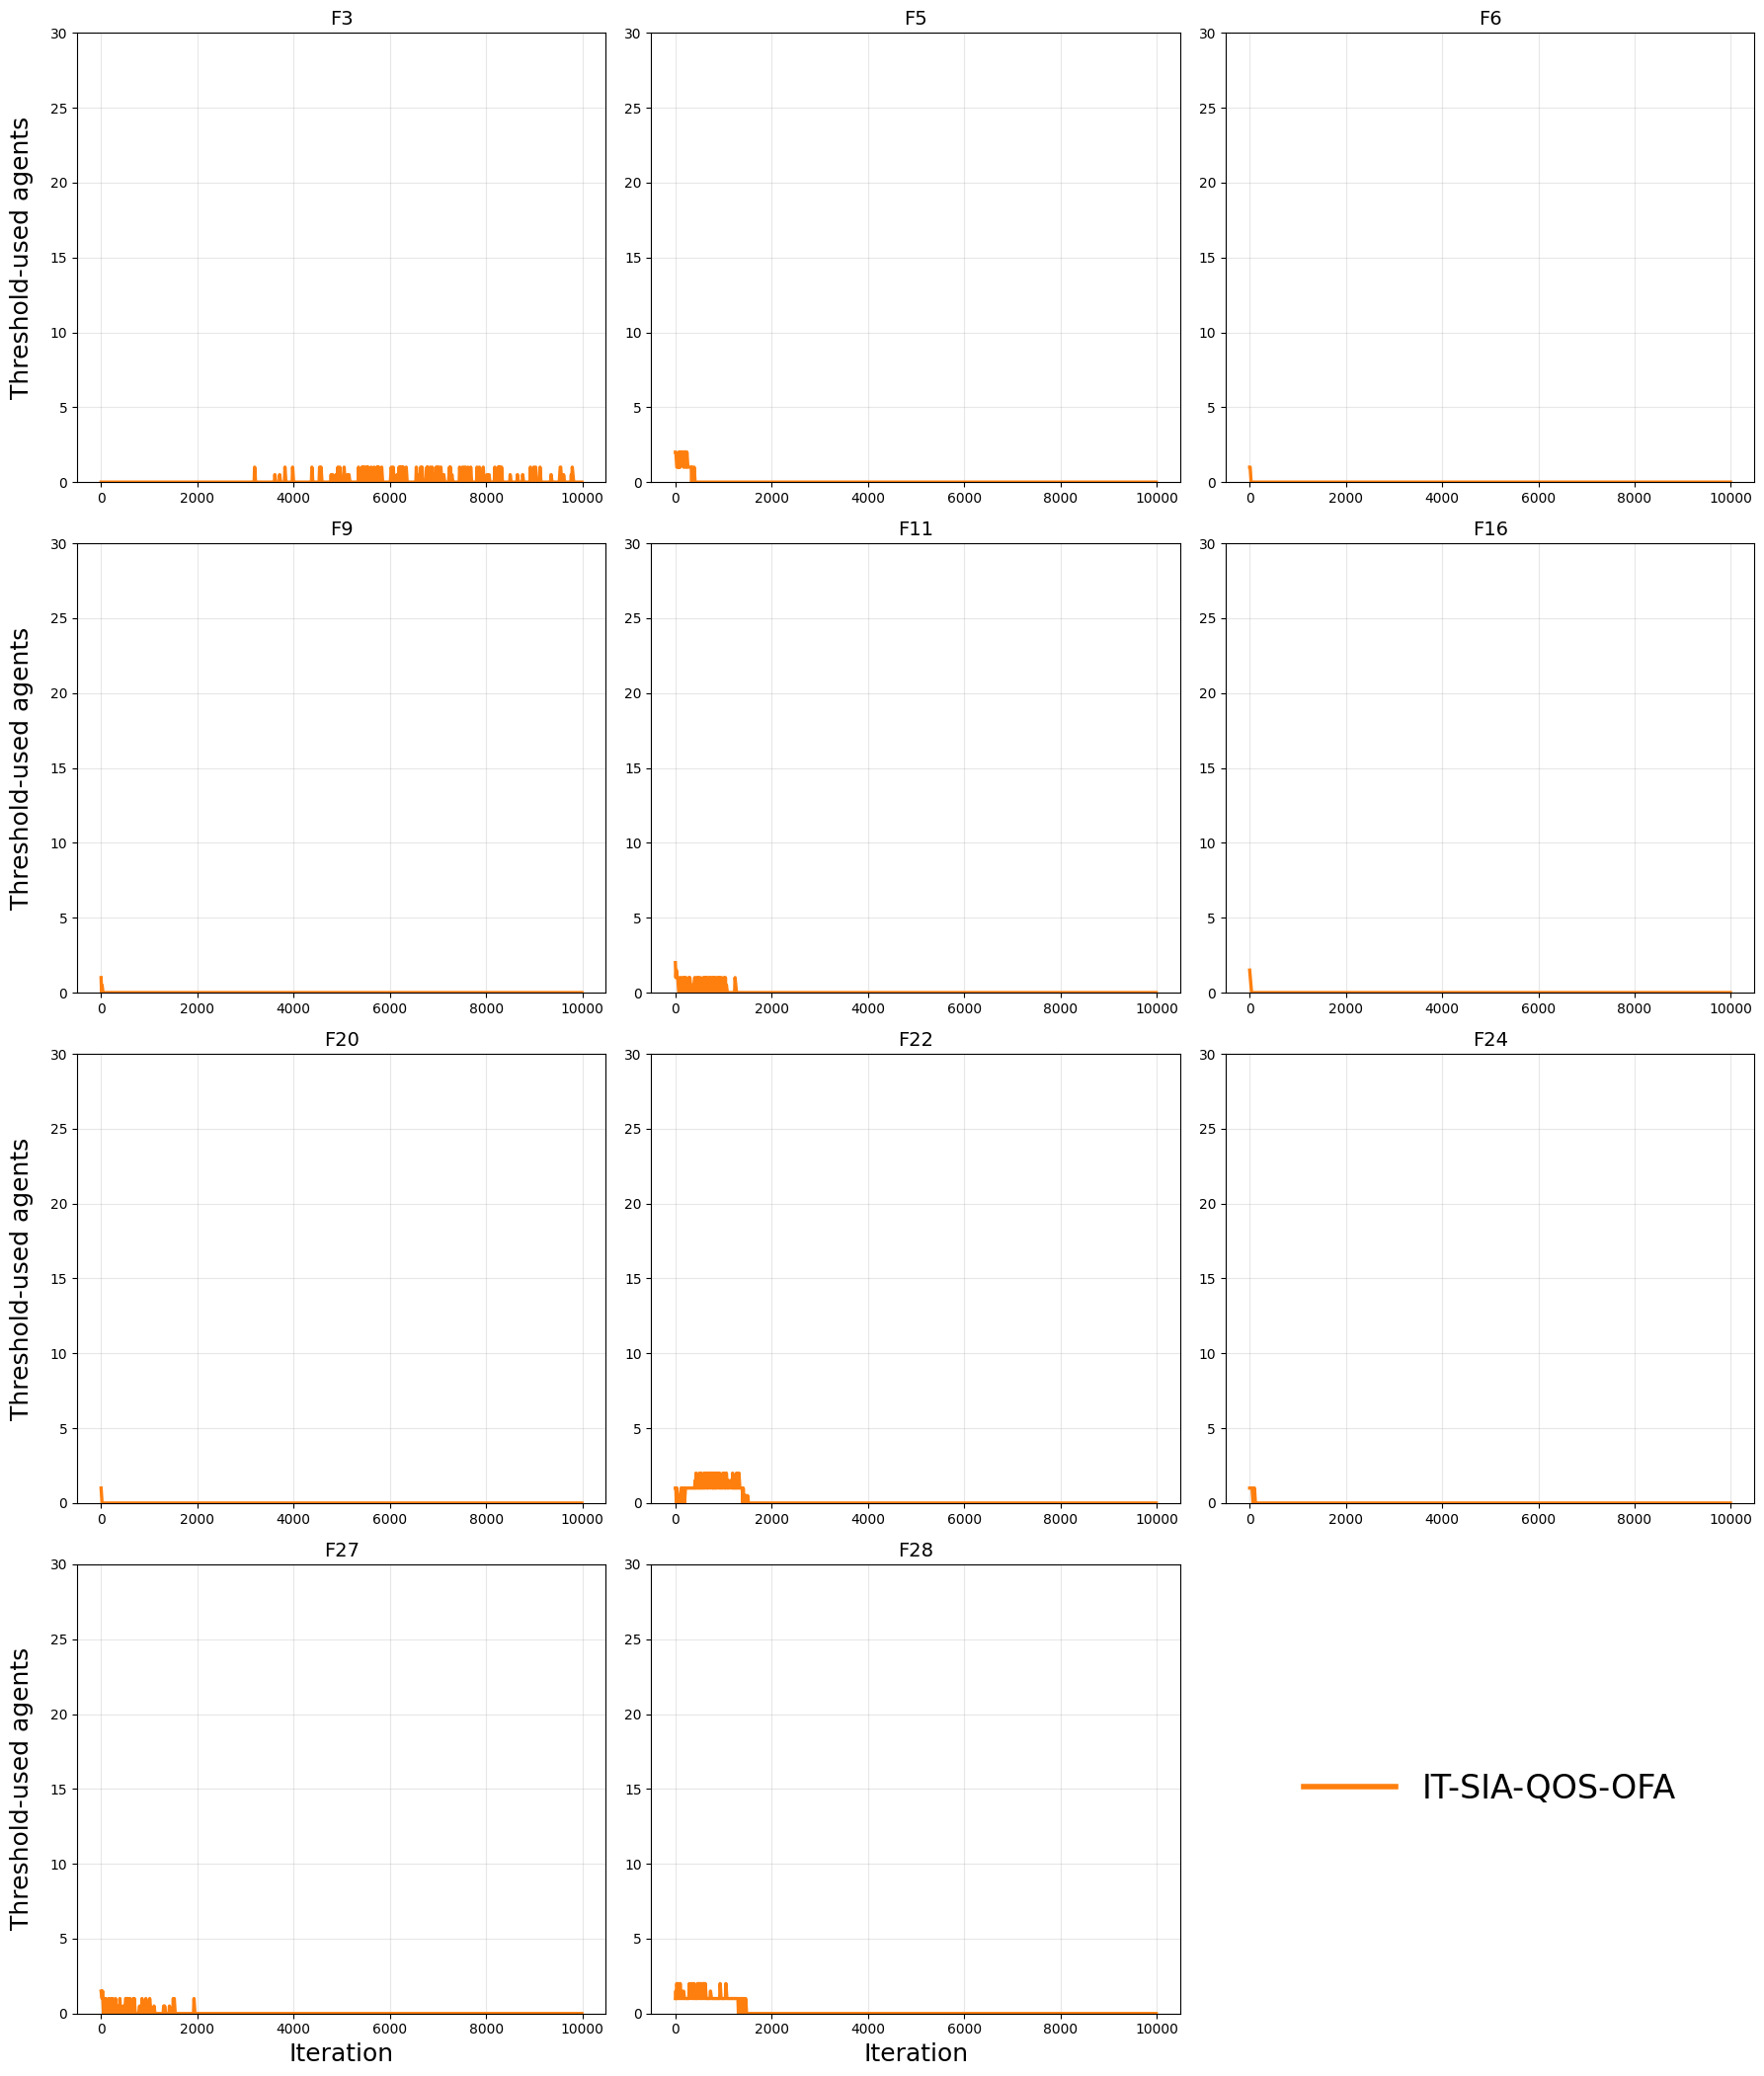

Saved SVG: Figures\it_sia_threshold_usage_count_grid_11functions.svg


,algorithm,objective_id,cec_func_num,objective_name,dim,T,num_agents,n_seeds,seed_start,seed_end,cec_bias,search_min_error_algorithm,search_max_error_algorithm,search_range_algorithm,search_min_source,search_max_source
0,IT-SIA-QOS-OFA,1,3,CEC Zakharov,30,10000,30,30,1,30,300.0,0.002014,5.995408e+13,5.995408e+13,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
1,IT-SIA-QOS-OFA,2,5,CEC Rastrigin,30,10000,30,30,1,30,500.0,66.467896,2.261603e+05,2.260939e+05,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
2,IT-SIA-QOS-OFA,3,6,CEC Expanded Scaffer's F6,30,10000,30,30,1,30,600.0,10.450012,1.506769e+01,4.617676e+00,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
3,IT-SIA-QOS-OFA,4,9,CEC Levy,30,10000,30,30,1,30,900.0,0.903625,6.133376e+04,6.133286e+04,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
4,IT-SIA-QOS-OFA,5,11,CEC Hybrid Function 1,30,10000,30,30,1,30,1100.0,23.711548,4.763035e+10,4.763035e+10,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
5,IT-SIA-QOS-OFA,8,16,CEC Hybrid Function 6,30,10000,30,30,1,30,1600.0,304.175903,4.262486e+04,4.232068e+04,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
6,IT-SIA-QOS-OFA,10,20,CEC Hybrid Function 10,30,10000,30,30,1,30,2000.0,146.672363,2.874191e+03,2.727519e+03,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
7,IT-SIA-QOS-OFA,11,22,CEC Composition Function 2,30,10000,30,30,1,30,2200.0,100.000977,1.298145e+04,1.288145e+04,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
8,IT-SIA-QOS-OFA,12,24,CEC Composition Function 4,30,10000,30,30,1,30,2400.0,409.170898,3.521068e+03,3.111897e+03,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations
9,IT-SIA-QOS-OFA,14,27,CEC Composition Function 7,30,10000,30,30,1,30,2700.0,458.878906,6.393315e+03,5.934437e+03,min over best_fit across seeds and iterations,max over worst_fit across seeds and iterations


In [ ]:
# Settings
ALGORITHM_LABEL = "IT-SIA-QOS-OFA"
ALGORITHM_COLOR = "tab:orange"

DIM = 30
T = 10000
NUM_AGENTS = 30
SEEDS = list(range(1,31))

TEMP_MIN = 0.05
TEMP_MAX = 1.0
ACCEPTANCE_STRENGTH = 0.20

EXCLUDED_CEC_FUNC_NUMS = {1,13,14,18,26,30}
SELECTED_CEC_FUNC_NUMS = [3,5,6,9,11,16,20,22,24,27,28]

OUTPUT_DIR = Path("analysis_exports")
OUTPUT_DIR.mkdir(exist_ok=True)

FIGURES_DIR = Path("Figures")
FIGURES_DIR.mkdir(exist_ok=True)

CONVERGENCE_OUTPUT_PATH = OUTPUT_DIR / "convergence_IT_SIA_QOS_OFA_all_usable_cec.xlsx"
PLOT_OUTPUT_PATH = FIGURES_DIR / "it_sia_threshold_usage_count_grid_11functions.svg"

Y_COL = "accepted_worse_count_median"
SVG_EVERY_N = 10

TITLE_FONTSIZE = 14
XLABEL_FONTSIZE = 18
YLABEL_FONTSIZE = 18
TICK_FONTSIZE = 10
LEGEND_FONTSIZE = 24
LEGEND_LINEWIDTH = 4

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["path.simplify"] = True
plt.rcParams["path.simplify_threshold"] = 0.5


# Safety
required_objects = ["bcec","get_objective_name","get_selected_cec_objective_ids","run_convergence_suite_for_algorithm","ITERATION_METRIC_NAMES"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        f"Missing required objects/functions: {missing_objects}\n\n"
        "Run the notebook cells that define the algorithm and convergence helpers first."
    )

if "accepted_worse_count" not in ITERATION_METRIC_NAMES:
    raise ValueError(
        "'accepted_worse_count' is not in ITERATION_METRIC_NAMES.\n"
        "Add it to the metric names and to metrics_t first."
    )


# CEC function selection
selected_objective_ids, cec_mapping_df = get_selected_cec_objective_ids(
    dim=DIM,exclude_func_nums=EXCLUDED_CEC_FUNC_NUMS
)

objective_ids = selected_objective_ids

print("Selected CEC functions:")
display(cec_mapping_df[cec_mapping_df["selected"] == True])

selected_func_nums_found = cec_mapping_df.loc[
    cec_mapping_df["selected"] == True,"cec_func_num"
].astype(int).tolist()

if selected_func_nums_found != SELECTED_CEC_FUNC_NUMS:
    print("WARNING: selected CEC function order differs from expected.")
    print("Expected:",SELECTED_CEC_FUNC_NUMS)
    print("Found:",selected_func_nums_found)


# Convergence run
conv_sia_df, per_run_sia_df, search_range_sia_df = run_convergence_suite_for_algorithm(
    algorithm_label=ALGORITHM_LABEL,objective_ids=objective_ids,dim=DIM,T=T,
    num_agents=NUM_AGENTS,seeds=SEEDS,excel_path=CONVERGENCE_OUTPUT_PATH,
    cec_module=bcec,
    run_kwargs={
        "temp_min": TEMP_MIN,
        "temp_max": TEMP_MAX,
        "acceptance_strength": ACCEPTANCE_STRENGTH,
    }
)

if Y_COL not in conv_sia_df.columns:
    raise ValueError(
        f"{Y_COL} was not created.\n\n"
        f"Available accepted_worse columns:\n{[c for c in conv_sia_df.columns if 'accepted_worse' in c.lower()]}\n\n"
        "This means the algorithm-definition code was not rerun after adding accepted_worse_count."
    )

print(f"Saved convergence workbook: {CONVERGENCE_OUTPUT_PATH}")
print("Accepted worse count columns:")
print([c for c in conv_sia_df.columns if "accepted_worse_count" in c])


# Plot data
usage_df = conv_sia_df.copy()
usage_df["cec_func_num"] = usage_df["cec_func_num"].astype(int)
usage_df = usage_df[usage_df["cec_func_num"].isin(SELECTED_CEC_FUNC_NUMS)].copy()

print("Maximum iteration:",int(usage_df["iteration"].max()))
print("Y column:",Y_COL)
print("SVG downsampling: every",SVG_EVERY_N,"iterations")


# Threshold-usage grid
def plot_threshold_usage_grid(df,*,cec_functions,output_path,nrows=4,ncols=3,figsize=(18,22)):
    total_slots = nrows * ncols

    if len(cec_functions) > total_slots:
        raise ValueError(
            f"Need at least {len(cec_functions)} subplot slots, "
            f"but only {total_slots} are available."
        )

    fig, axes = plt.subplots(nrows,ncols,figsize=figsize)
    axes = axes.flatten()

    legend_handle = Line2D(
        [0],[0],color=ALGORITHM_COLOR,linewidth=LEGEND_LINEWIDTH,label="IT-SIA-QOS-OFA"
    )

    for idx, cec_func_num in enumerate(cec_functions):
        ax = axes[idx]

        df_func = df[df["cec_func_num"] == cec_func_num].copy().sort_values("iteration")

        if df_func.empty:
            ax.axis("off")
            continue

        # SVG downsampling
        df_func = df_func.iloc[::SVG_EVERY_N,:]

        x = df_func["iteration"].to_numpy(dtype=float)
        y = df_func[Y_COL].to_numpy(dtype=float)

        ax.plot(x,y,linewidth=2.4,color=ALGORITHM_COLOR,label=ALGORITHM_LABEL)

        ax.set_title(f"F{cec_func_num}",fontsize=TITLE_FONTSIZE)
        ax.set_ylim(0,NUM_AGENTS)

        if idx // ncols == nrows - 1:
            ax.set_xlabel("Iteration",fontsize=XLABEL_FONTSIZE)
        else:
            ax.set_xlabel("")

        if idx % ncols == 0:
            ax.set_ylabel("Threshold-used agents",fontsize=YLABEL_FONTSIZE,labelpad=12)
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="both",labelsize=TICK_FONTSIZE)
        ax.grid(True,alpha=0.3)

    # Unused subplots
    for j in range(len(cec_functions),total_slots):
        axes[j].axis("off")

    # Legend subplot
    legend_ax = axes[total_slots - 1]
    legend_ax.axis("off")
    legend_ax.legend(
        handles=[legend_handle],loc="center",frameon=False,fontsize=LEGEND_FONTSIZE,
        handlelength=2.8,labelspacing=1.2
    )

    fig.tight_layout(rect=[0,0.02,1,0.98])

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True,exist_ok=True)

    fig.savefig(output_path,bbox_inches="tight",format="svg")

    plt.show()
    print(f"Saved SVG: {output_path}")

    return fig


fig_threshold_usage = plot_threshold_usage_grid(
    usage_df,cec_functions=SELECTED_CEC_FUNC_NUMS,output_path=PLOT_OUTPUT_PATH,
    nrows=4,ncols=3,figsize=(18,22)
)

display(search_range_sia_df)

# Analysis of the IT-SIA rule

In [ ]:
# Settings
CONVERGENCE_PATH = Path("analysis_exports/convergence_IT_SIA_QOS_OFA_all_usable_cec.xlsx")
SHEET_NAME = "convergence_all"

OUTPUT_EXCEL_PATH = Path("analysis_exports/it_sia_accepted_worse_percentage_table.xlsx")
OUTPUT_TEX_PATH = Path("Tables/it_sia_accepted_worse_percentage_table.tex")

SELECTED_CEC_FUNC_NUMS = [3,5,6,9,11,16,20,22,24,27,28]
NUM_AGENTS = 30

OUTPUT_EXCEL_PATH.parent.mkdir(parents=True,exist_ok=True)
OUTPUT_TEX_PATH.parent.mkdir(parents=True,exist_ok=True)


# Loading convergence data
if not CONVERGENCE_PATH.exists():
    raise FileNotFoundError(f"Could not find: {CONVERGENCE_PATH}")

df = pd.read_excel(CONVERGENCE_PATH,sheet_name=SHEET_NAME)
df["cec_func_num"] = df["cec_func_num"].astype(int)
df = df[df["cec_func_num"].isin(SELECTED_CEC_FUNC_NUMS)].copy()


# Safety
required_cols = ["cec_func_num","objective_name","iteration","accepted_worse_count_mean","acceptance_rate_mean"]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(
        f"Missing required columns: {missing_cols}\n\n"
        f"Available accepted_worse columns:\n{[c for c in df.columns if 'accepted_worse' in c.lower()]}\n\n"
        f"Available acceptance columns:\n{[c for c in df.columns if 'acceptance' in c.lower()]}"
    )


# Accepted move counts
df["accepted_moves_mean_count"] = df["acceptance_rate_mean"].astype(float) * NUM_AGENTS
df["accepted_worse_moves_mean_count"] = df["accepted_worse_count_mean"].astype(float)


# Function-level percentages
summary_rows = []

for cec_func_num in SELECTED_CEC_FUNC_NUMS:
    df_func = df[df["cec_func_num"] == cec_func_num].copy()

    if df_func.empty:
        continue

    objective_name = df_func["objective_name"].iloc[0]
    accepted_worse_total = df_func["accepted_worse_moves_mean_count"].sum()
    accepted_total = df_func["accepted_moves_mean_count"].sum()

    accepted_worse_percentage = 100.0 * accepted_worse_total / accepted_total if accepted_total > 0 else np.nan

    summary_rows.append({
        "CEC function": f"F{cec_func_num}",
        "Objective name": objective_name,
        "Mean accepted worse moves": accepted_worse_total,
        "Mean accepted moves": accepted_total,
        "Accepted worse among accepted (%)": accepted_worse_percentage,
    })

table_df = pd.DataFrame(summary_rows)


# Weighted overall row
overall_accepted_worse = table_df["Mean accepted worse moves"].sum()
overall_accepted = table_df["Mean accepted moves"].sum()
overall_weighted_percentage = 100.0 * overall_accepted_worse / overall_accepted if overall_accepted > 0 else np.nan

overall_weighted_row = pd.DataFrame([{
    "CEC function": "Overall weighted",
    "Objective name": "All selected functions",
    "Mean accepted worse moves": overall_accepted_worse,
    "Mean accepted moves": overall_accepted,
    "Accepted worse among accepted (%)": overall_weighted_percentage,
}])


# Mean-across-functions row
mean_across_functions_percentage = table_df["Accepted worse among accepted (%)"].mean()

mean_across_functions_row = pd.DataFrame([{
    "CEC function": "Mean across functions",
    "Objective name": "Unweighted mean",
    "Mean accepted worse moves": np.nan,
    "Mean accepted moves": np.nan,
    "Accepted worse among accepted (%)": mean_across_functions_percentage,
}])

table_df = pd.concat([table_df,overall_weighted_row,mean_across_functions_row],ignore_index=True)


# Display table
display_df = table_df.copy()

display_df["Mean accepted worse moves"] = display_df["Mean accepted worse moves"].round(2)
display_df["Mean accepted moves"] = display_df["Mean accepted moves"].round(2)
display_df["Accepted worse among accepted (%)"] = display_df["Accepted worse among accepted (%)"].round(4)

display(display_df)


# Saving Excel
display_df.to_excel(OUTPUT_EXCEL_PATH,index=False)
print(f"Saved Excel table: {OUTPUT_EXCEL_PATH}")


# Saving LaTeX
latex_df = display_df.copy()

latex_table = latex_df.to_latex(
    index=False,escape=True,
    caption="Percentage of accepted worse proposed moves among all accepted proposed moves for IT-SIA-QOS-OFA.",
    label="tab:it_sia_accepted_worse_percentage",column_format="llrrr"
)

OUTPUT_TEX_PATH.write_text(latex_table,encoding="utf-8")
print(f"Saved LaTeX table: {OUTPUT_TEX_PATH}")

,CEC function,Objective name,Mean accepted worse moves,Mean accepted moves,Accepted worse among accepted (%)
0,F3,CEC Zakharov,4052.13,22255.03,18.2077
1,F5,CEC Rastrigin,790.53,3559.10,22.2116
2,F6,CEC Expanded Scaffer's F6,103.00,475.47,21.6629
3,F9,CEC Levy,1498.90,7114.40,21.0685
4,F11,CEC Hybrid Function 1,1985.57,9148.63,21.7034
5,F16,CEC Hybrid Function 6,122.67,712.60,17.2140
6,F20,CEC Hybrid Function 10,137.87,675.70,20.4035
7,F22,CEC Composition Function 2,2403.57,93804.51,2.5623
8,F24,CEC Composition Function 4,251.33,1243.00,20.2199
9,F27,CEC Composition Function 7,2864.07,26742.83,10.7097


Saved Excel table: analysis_exports\it_sia_accepted_worse_percentage_table.xlsx
Saved LaTeX table: Tables\it_sia_accepted_worse_percentage_table.tex
